# Comparing Calibration Data Across All Models / Question Sets

In [1]:
%%capture
%pip install -r requirements.txt

In [2]:
# Initialize
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from pathlib import Path
import json


## Combine All Results Into Composite CSV

First we will read from the Parsed Results folder and make a dictionary that abstracts the structure of the directory

In [3]:
# Read the folder and create a dictionary to model the structure of the files

def folder_tree_dict(root, *, include_files=True, follow_symlinks=False, ignore_hidden=True):
    root = Path(root)

    def build(p: Path):
        out = {}
        for entry in sorted(p.iterdir(), key=lambda x: (x.is_file(), x.name.lower())):
            if ignore_hidden and entry.name.startswith("."):
                continue
            try:
                if entry.is_dir() and (follow_symlinks or not entry.is_symlink()):
                    out[entry.name] = build(entry)
                else:
                    if include_files:
                        out[entry.name] = None  # or {"size": entry.stat().st_size}
            except PermissionError:
                out[entry.name] = "<permission-denied>"
        return out

    return {root.name: build(root)}


folder_path = r"Parsed Results"

folder_abstraction_dict = folder_tree_dict(folder_path)[folder_path]

folder_abstraction_dict.keys()

dict_keys(['Claude', 'Deepseek', 'Gemini', 'GPT', 'Llama'])

### Combined CSV
We want to make a well-formed CSV for future analysis. This CSV will have the following fields for columns:

```text
Question Set (str) ---------------- Required: The display name of the question set
Question ID (str) ----------------- Required: The Question ID
Model (str) ----------------------- Required: The model that provided the response (e.g. Llama-3.1-8B-Instruct)
Model Type (str) ------------------ Required: The family of models which  the model (e.g. Llama)
Coerce (Bool) --------------------- Required: Whether the parser was able to understand the response

Question (str) -------------------- Required: The question posed to the model
Correct Answer (str) -------------- Optional: Depends on Question Set (LifeEval is different than others)
Content (str) --------------------- Optional: Depends on Coerce value (NA if Coerce == False)
Reasoning (str) ------------------- Optional: Depends on Coerce value (NA if Coerce == False)
Answer (str) ---------------------- Optional: Depends on Coerce value (NA if Coerce == False)
Score (float) --------------------- Optional: Depends on Coerce value (NA if Coerce == False)

Stated Confidence Answer (float) -- Optional: Depends on Question Set (NA if not available)
Stated Confidence A (float) ------- Optional: Depends on Question Set (NA if not available)
Stated Confidence B (float) ------- Optional: Depends on Question Set (NA if not available)
Stated Confidence C (float) ------- Optional: Depends on Question Set (NA if not available)
Stated Confidence D (float) ------- Optional: Depends on Question Set (NA if not available)
Stated Confidence E (float)-------- Optional: Depends on Question Set (NA if not available)

Token Probability Answer (float) -- Optional: Depends on Model Type (NA if not available)
Token Probability A (float) ------- Optional: Depends on Model Type (NA if not available)
Token Probability B (float) ------- Optional: Depends on Model Type (NA if not available)
Token Probability C (float) ------- Optional: Depends on Model Type (NA if not available)
Token Probability D (float) ------- Optional: Depends on Model Type (NA if not available)
Token Probability E (float) ------- Optional: Depends on Model Type (NA if not available)

```

---
### Process All CSVs Into One

### Grading:

In [4]:
def grade_df(source_df, gold_df, qset_name):
    df = source_df.copy()
    mask = df.index
    #print(f"            Length: {len(mask)}")
    
    if qset_name in mcq_qsets:
        # Make sure the QIDs are in the right order
        df["Question ID"] = df["Question ID"].astype(int) 
        df = df.sort_values(by="Question ID", ascending=True).reset_index()
        df["Question ID"] = df["Question ID"].astype(str)  ## make sure back as str for downstream tasks

        gold_df["Question ID"] = gold_df["Question ID"].astype(str)
        temp = pd.merge(source_df, gold_df, on = "Question ID")
        scores = (temp["Answer"].str.lower().str.strip() == temp["Correct Answer Letter"].str.lower().str.strip()).astype(float)
        df["Score"] = scores
        df['Correct Answer'] = temp["Correct Answer Letter"].str.upper().str.strip()

        # assumes stated confidences live in columns ["A","B","C","D"]
        if qset_name == "LSAT-AR":
            opt_cols = ["A","B","C","D", "E"]
            # normalize answer letters
            ans = df["Answer"].astype("string").str.strip().str.upper()

            # map letters to column indices
            idx = ans.map({"A":0, "B":1, "C":2, "D":3, "E":4 }).to_numpy()
        else:
            opt_cols = ["A","B","C","D"]
            # normalize answer letters
            ans = df["Answer"].astype("string").str.strip().str.upper()

            # map letters to column indices
            idx = ans.map({"A":0, "B":1, "C":2, "D":3}).to_numpy()

        vals = df[opt_cols].apply(pd.to_numeric, errors="coerce").to_numpy()
        mask = ~np.isnan(idx)

        chosen = np.full(len(df), np.nan, dtype=float)
        chosen[mask] = vals[mask, idx[mask].astype(int)]
        df["Stated Confidence Answer (MCQ)"] = chosen


    elif qset_name == "BoolQ":
        # Make sure the QIDs are in the right order
        # df["Question ID"] = df["Question ID"].astype(int) 
        # df = df.sort_values(by="Question ID", ascending=True).reset_index()
        # df["Question ID"] = df["Question ID"].astype(str)  ## make sure back as str for downstream tasks

        gold_df["Question ID"] = gold_df["Question ID"].astype(str)
        temp = pd.merge(source_df, gold_df, on = "Question ID")

        bscores = (temp["Answer"].astype(str) == temp["Correct Answer"].astype(str)).astype(float)
        df["Score"] = bscores
        df['Correct Answer'] = temp["Correct Answer"].astype(str)
        
    elif qset_name == "HaluEval":
        df["Score"] = df["Question ID"].str.contains("_r").astype(float)
    else:
        df["Score"] = "UNRECOGINIZED QUESTION SET"
    """
    Don wants: one column that indicates stated confidence in the correct answer, with remaining 
    in correct answers in different columns.
    (It would of course follow that token prob should be reorganized the same way.) 

    Currently we evaluate the whether the answer was correct and then the confidence it was assigned. Is this different?
    Don's Approach: Grade the question based off of the correct answer.
    My Approach: Grade the question based off of the chosen answer.
    """
    #print(f"            Length: {len(df)}")
    return df

### Combining:

In [5]:
combined_df = pd.DataFrame()
clean_df = pd.DataFrame()

qset_rename = {
 'boolq_valid': "BoolQ",
 'halu_eval_qa': "HaluEval",
 'lsat_ar_test': "LSAT-AR",
 'sat_en': "SAT-EN",
 'sciq_test':"SciQ"
}

gold_paths = {
    "BoolQ": r"Formatted Benchmarks/boolq_valid_formatted.csv",
    "HaluEval": r"Formatted Benchmarks/halu_eval_qa_formatted.csv",
    "LSAT-AR": r"Formatted Benchmarks/lsat_ar_test_formatted.csv", 
    "SAT-EN": r"Formatted Benchmarks/sat_en_formatted.csv",
    "SciQ": r"Formatted Benchmarks/sciq_test_formatted.csv"    
}


mcq_qsets = ['LSAT-AR', 'SAT-EN', 'SciQ']


for model_type, models in folder_abstraction_dict.items():
    model_type_path = folder_path + f"/{model_type}"
    print(model_type_path)
    for model_name, qsets in models.items():
        model_path = model_type_path + f"/{model_name}"
        print(f"    {model_path}")
        for qset_file_name in qsets:
            splitter = f"_{model_name}"
            qset_name = qset_file_name.split(splitter)[0]
            qset_path = model_path + f"/{qset_file_name}"
            
            #--------- Write a function to spit out a dataframe w/ model_name, qset_name, true_answer and concat it

            source_df = pd.read_csv(qset_path)


            print(f"        {qset_name}    ")

            source_df["Model"] = model_name
            source_df["Model Type"] = model_type

            qset_display = qset_rename[qset_name]
            source_df["Question Set"] = qset_display
            source_df["Question ID"] = source_df["Question ID"].astype(str)

            gold_df_path = gold_paths[qset_display]

            gold_df = pd.read_csv(gold_df_path)
            
            scored_qset = grade_df(source_df = source_df, gold_df = gold_df, qset_name= qset_display)

            combined_df = pd.concat([combined_df, scored_qset], ignore_index=True)




combined_df.drop(["Unnamed: 0", "Question ID.1"], axis = 1, inplace = True, errors = "ignore")

## Still need to add correct answer and score

col_rename_map ={
# Metadata
'Question Set': "Question Set",
'Question ID': "Question ID",
'Model': "Model",
'Model Type': "Model Type",
'coerce': "Coerce",

# Model Response

'content': "Content",
'Reasoning': "Reasoning",
'Answer': "Answer",

# Stated Confidence
'Confidence': "Stated Confidence Answer",
"A": "Stated Confidence A",
"B": "Stated Confidence B",
'C': "Stated Confidence C",
'D': "Stated Confidence D",
'E': "Stated Confidence E",

# Token Probability
'True_prob': "Token Probability True",
'False_prob': "Token Probability False",
'Answer_prob': "Token Probability Answer",
'A_prob': "Token Probability A",
'B_prob': "Token Probability B",
'C_prob': "Token Probability C",
'D_prob': "Token Probability D",
'E_prob': "Token Probability E"
}

combined_df = combined_df.rename(columns = col_rename_map)

qset_rename = {
 'boolq_valid': "BoolQ",
 'halu_eval_qa': "HaluEval",
 'lsat_ar_test': "LSAT-AR",
 'sat_en': "SAT-EN",
 'sciq_test':"SciQ"
}

#combined_df["Question Set"] = combined_df["Question Set"].map(qset_rename)

with pd.option_context('display.max_columns', None,
                       #'display.width', None,
                       #'display.max_colwidth', None
                       ):
    display(combined_df.head(5))


raw_path   = Path("Combined Results/combined_raw.csv")
combined_df.to_csv(raw_path, index=False, encoding="utf-8")



Parsed Results/Claude
    Parsed Results/Claude/claude-3-7-sonnet-20250219
        boolq_valid    
        halu_eval_qa    


        lsat_ar_test    
        sat_en    
        sciq_test    
    Parsed Results/Claude/claude-3-haiku-20240307


        boolq_valid    
        halu_eval_qa    
        lsat_ar_test    
        sat_en    


        sciq_test    
    Parsed Results/Claude/claude-sonnet-4-20250514
        boolq_valid    


        halu_eval_qa    
        lsat_ar_test    
        sat_en    
        sciq_test    


...

        sat_en    
        sciq_test    


    Parsed Results/Llama/Meta-Llama-3.1-8B-Instruct
        boolq_valid    
        halu_eval_qa    


        lsat_ar_test    
        sat_en    


        sciq_test    


,Reasoning,Answer,Stated Confidence Answer,Coerce,Content,Question ID,Model,Model Type,Question Set,Score,Correct Answer,index,Stated Confidence A,Stated Confidence B,Stated Confidence C,Stated Confidence D,Stated Confidence E,Stated Confidence Answer (MCQ),Token Probability True,Token Probability False,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E
0,The question is asking whether the production ...,False,0.60,True,"{\n ""Reasoning"": ""The question is asking wh...",0,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,House tax and property tax are often used inte...,True,0.85,True,"{\n ""Reasoning"": ""House tax and property ta...",1,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,This question is asking about phantom limb pai...,True,0.95,True,"{\n ""Reasoning"": ""This question is asking a...",2,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Harry Potter and the Escape from Gringotts is ...,True,0.98,True,"{\n ""Reasoning"": ""Harry Potter and the Esca...",3,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hydroxyzine HCl (hydrochloride) and hydroxyzin...,True,0.98,True,"{\n ""Reasoning"": ""Hydroxyzine HCl (hydrochl...",4,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Gini Function

In [6]:
import math
def norm_gini(data):
    # 1. Filter out Non-numbers and NaNs immediately
    clean_data = [x for x in data if x is not None and not np.isnan(x)]
    
    # 2. Handle empty lists after cleaning
    if not clean_data:
        return 0.0
        
    # 3. Standard Logic...
    sorted_data = sorted(clean_data)
    n = len(clean_data)
    total = sum(sorted_data)
    
    if total == 0:
        return 0.0
    
    numerator = 0
    for i, x in enumerate(sorted_data, 1):
        numerator += (2 * i - n - 1) * x

    g = numerator / (n * total)
    g_max = (n-1)/ n
    return g / g_max

combined_df['gini'] = combined_df.apply(lambda row: norm_gini([
    row['Stated Confidence A'],
    row['Stated Confidence B'],
    row['Stated Confidence C'],
    row['Stated Confidence D'],
    row['Stated Confidence E']
    ]), axis = 1)

combined_df.loc[~combined_df['Question Set'].isin(mcq_qsets), 'gini'] = float('nan')

combined_df[combined_df['Question Set'] == 'BoolQ'].head()

,Reasoning,Answer,Stated Confidence Answer,Coerce,Content,Question ID,Model,Model Type,Question Set,Score,...,Stated Confidence E,Stated Confidence Answer (MCQ),Token Probability True,Token Probability False,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E,gini
0,The question is asking whether the production ...,False,0.60,True,"{\n ""Reasoning"": ""The question is asking wh...",0,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,House tax and property tax are often used inte...,True,0.85,True,"{\n ""Reasoning"": ""House tax and property ta...",1,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,This question is asking about phantom limb pai...,True,0.95,True,"{\n ""Reasoning"": ""This question is asking a...",2,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Harry Potter and the Escape from Gringotts is ...,True,0.98,True,"{\n ""Reasoning"": ""Harry Potter and the Esca...",3,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hydroxyzine HCl (hydrochloride) and hydroxyzin...,True,0.98,True,"{\n ""Reasoning"": ""Hydroxyzine HCl (hydrochl...",4,claude-3-7-sonnet-20250219,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clean DataFrame

**LifeEval filter.** LifeEval is archived (see `archive/lifeeval/`) and actively
developed in `study-2-bayeseval/`. The canonical `combined_raw.csv` keeps its rows
as the preregistered record, so we drop them here. All LifeEval-specific analysis
cells have been removed from this notebook; see the archive for that record.


In [7]:
# combined_clean is produced by the canonical cleaning pipeline (clean.py), which
# drops LifeEval (archived), bad/uncoerced QIDs, and normalizes confidences.
# Run `python clean.py` first if Parsed Results have changed.
combined_df = combined_df[combined_df["Question Set"] != "LifeEval"]
combined_clean = pd.read_csv("Combined Results/combined_clean.csv", low_memory=False)
combined_clean["Question ID"] = combined_clean["Question ID"].astype(str)
combined_clean["Question Set"].unique()

<ArrowStringArray>
['BoolQ', 'HaluEval', 'LSAT-AR', 'SAT-EN', 'SciQ']
Length: 5, dtype: str

# Summary Info

Here we see the Raw versus Filtered counts for all the datasets.

In [8]:
counts = pd.DataFrame({
    "Raw": combined_df["Question Set"].value_counts() / 11, # This is slightly below 2000 for Llama because we had to drop 3 duplicates
    "Filtered": combined_clean["Question Set"].value_counts() / 11
})

counts[~counts.index.isin(mcq_qsets)]

counts["Prop. Kept"] = counts["Filtered"] / counts["Raw"]
counts
# Need to look at: LSAT-AR (-1)???,  Sciq(-1) Im getting rid of too much?

,Raw,Filtered,Prop. Kept
Question Set,,,
BoolQ,3270.000000,2503.0,0.765443
HaluEval,1998.909091,1790.0,0.895488
LSAT-AR,229.909091,86.0,0.374061
SAT-EN,206.000000,173.0,0.839806
SciQ,1000.000000,995.0,0.995000


In [9]:
combined_df[combined_df["Coerce"] == True].pivot_table(index="Model", columns="Question Set",
                        aggfunc="size", fill_value=0)

Question Set,BoolQ,HaluEval,LSAT-AR,SAT-EN,SciQ
Model,,,,,
Meta-Llama-3.1-70B-Instruct,3241,1960,208,202,1000
Meta-Llama-3.1-8B-Instruct,3200,1997,190,202,997
claude-3-7-sonnet-20250219,3267,2000,228,206,999
claude-3-haiku-20240307,3036,1855,230,181,999
claude-sonnet-4-20250514,3258,2000,188,205,1000
deepseek-r1,3214,2000,228,206,1000
deepseek-v3,2898,2000,228,204,1000
gemini-2.5-flash,3261,2000,177,206,1000
gemini-2.5-pro,3190,1984,188,204,1000


---
We had some notable differences from Jacob's results in **LSAT-AR** and **SciQ**. Let's take a look.

In [10]:
sciq_filtered = combined_clean[combined_clean["Question Set"] == "SciQ"]
sciq_raw = combined_df[combined_df["Question Set"] == "SciQ"]


sciq_filtered_ids = sciq_filtered.index

deleted = sciq_raw[~sciq_raw.index.isin(sciq_filtered_ids)]
deleted["Question ID"].unique()

# Deleted QID in SciQ are ['13', '40', '295', '699', '705'] after visual inspection they all seem to have False coerce values in one of 11 rows


false_counts = (deleted['Coerce'].eq(False)
                .groupby(deleted['Question ID'])
                .sum()
                .rename('false_count'))

# as a DataFrame
false_counts = false_counts.reset_index()
false_counts


,Question ID,false_count
0,0,0
1,1,0
2,10,0
3,100,0
4,101,0
...,...,...
995,995,0
996,996,0
997,997,0
998,998,0


Jacob's cleaned version of SciQ has 996 QIDs while mine has 995. When investigating each deleted Question ID in my version we find that they all have 1 instance where the answer could not be coerced. Does Jacob have an extra question that shouldn't be there?

---
Looking at LSAT-AR we see that Jacob had 87 QIDs while mine had 86. Let's investigate the difference.

In [11]:

lsat_filtered = combined_clean[combined_clean["Question Set"] == "LSAT-AR"]
lsat_raw = combined_df[combined_df["Question Set"] == "LSAT-AR"]


lsat_filtered_ids = lsat_filtered.index

deleted = lsat_raw[~lsat_raw.index.isin(lsat_filtered_ids)]
deleted["Question ID"].unique()



false_counts = (deleted['Coerce'].eq(False)
                .groupby(deleted['Question ID'])
                .sum()
                .rename('false_count'))

# as a DataFrame
false_counts = false_counts.reset_index()

# There is one QID that was removed while having all coerce values as True. Lets investigate:
special_qid = list(false_counts[false_counts['false_count'] == 0]['Question ID'])
print(f"Special Question IDs: {special_qid}")

# At some point QID 64
bad_qid_confidence = lsat_raw[lsat_raw['Question ID'].isin(special_qid)][["Question ID", "Coerce", "Model", "Stated Confidence A", "Stated Confidence B", "Stated Confidence C","Stated Confidence D","Stated Confidence E",]]#.sum(axis =1)

bad_qid_confidence['Sum'] = bad_qid_confidence.sum(axis=1, numeric_only = True)
bad_qid_confidence

Special Question IDs: ['0', '10', '100', '101', '103', '104', '105', '106', '107', '108', '109', '11', '112', '115', '122', '123', '127', '128', '130', '131', '132', '135', '139', '14', '141', '142', '144', '145', '147', '15', '155', '16', '160', '162', '163', '166', '17', '172', '178', '180', '181', '182', '184', '185', '189', '2', '20', '202', '203', '204', '205', '207', '211', '212', '213', '216', '219', '220', '222', '228', '24', '27', '29', '3', '30', '35', '4', '43', '5', '53', '61', '64', '7', '71', '73', '75', '77', '8', '87', '88', '89', '90', '91', '94', '95', '97', '99']


,Question ID,Coerce,Model,Stated Confidence A,Stated Confidence B,Stated Confidence C,Stated Confidence D,Stated Confidence E,Sum
5270,0,True,claude-3-7-sonnet-20250219,0.0,0.00,0.95,0.05,0.00,2.0
5272,2,True,claude-3-7-sonnet-20250219,0.0,0.10,0.70,0.10,0.10,2.0
5273,3,True,claude-3-7-sonnet-20250219,0.7,0.00,0.00,0.15,0.15,2.0
5274,4,True,claude-3-7-sonnet-20250219,0.0,0.00,0.00,0.95,0.05,2.0
5275,5,True,claude-3-7-sonnet-20250219,0.1,0.15,0.60,0.05,0.10,2.0
...,...,...,...,...,...,...,...,...,...
72533,216,True,Meta-Llama-3.1-8B-Instruct,0.0,0.80,0.00,0.00,0.20,2.0
72536,219,True,Meta-Llama-3.1-8B-Instruct,0.0,0.00,0.95,0.00,0.05,2.0
72537,220,True,Meta-Llama-3.1-8B-Instruct,0.0,0.00,1.00,0.00,0.00,2.0
72539,222,True,Meta-Llama-3.1-8B-Instruct,0.0,0.00,0.00,0.00,1.00,2.0


Question ID 64 in LSAT-AR only had 10 answered instances. Notably, GPT-o3 failed to respond. Because of this, we dropped it from the analysis.

In [12]:
# Jacob's file:

jb_df = pd.read_csv("Combined Results/llm-confidence-correct.csv")
jb_df.shape, combined_clean.shape

## SciQ
jb_qid = jb_df[jb_df["qset"] == "sciq_test"]["question_id"].unique()
my_qid = combined_clean[combined_clean["Question Set"] == "SciQ"]["Question ID"].unique()

# elements not in the intersection (i.e., in exactly one array)
not_in_intersection = np.setxor1d(jb_qid, my_qid)

# if you also want side-specific lists:
only_in_jb = np.setdiff1d(jb_qid, my_qid)
only_in_me = np.setdiff1d(my_qid, jb_qid)

only_in_jb


## LSAT-AR
jb_qid = jb_df[jb_df["qset"] == "lsat_ar_test"]["question_id"].unique()
my_qid = combined_clean[combined_clean["Question Set"] == "LSAT-AR"]["Question ID"].unique()

# elements not in the intersection (i.e., in exactly one array)
not_in_intersection = np.setxor1d(jb_qid, my_qid)

# if you also want side-specific lists:
only_in_jb = np.setdiff1d(jb_qid, my_qid)
only_in_me = np.setdiff1d(my_qid, jb_qid)

print(f"Unique Question IDs for LSAT-AR in Jacob's Work: {only_in_jb}")

Unique Question IDs for LSAT-AR in Jacob's Work: ['1' '102' '110' '111' '113' '114' '116' '117' '118' '119' '12' '120'
 '121' '124' '125' '126' '129' '13' '133' '134' '136' '137' '138' '140'
 '143' '146' '148' '149' '150' '151' '152' '153' '154' '156' '157' '158'
 '159' '161' '164' '165' '167' '168' '169' '170' '171' '173' '174' '175'
 '176' '177' '179' '18' '183' '186' '187' '188' '19' '190' '191' '192'
 '193' '194' '195' '196' '197' '198' '199' '200' '201' '206' '208' '209'
 '21' '210' '214' '215' '217' '218' '22' '221' '223' '224' '225' '226'
 '227' '229' '23' '25' '26' '28' '31' '32' '33' '34' '36' '37' '38' '39'
 '40' '41' '42' '44' '45' '46' '47' '48' '49' '50' '51' '52' '54' '55'
 '56' '57' '58' '59' '6' '60' '62' '63' '64' '65' '66' '67' '68' '69' '70'
 '72' '74' '76' '78' '79' '80' '81' '82' '83' '84' '85' '86' '9' '92' '93'
 '96' '98']


## Save all DataFrames to CSVs



In [13]:
# combined_clean.csv is owned by clean.py; this notebook only reads it.
print(f"""CSV Shapes:\n{'-'*60}
Raw: {combined_df.shape}
Cleaned: {combined_clean.shape}
      """)

CSV Shapes:
------------------------------------------------------------
Raw: (73753, 26)
Cleaned: (61017, 27)
      


# Analysis

---
First lets compare ECE scores for all modelson all question sets.

In [14]:
## ECE function

def get_ece(s: pd.Series, c: pd.Series, n_bins: int = 10):
    # Ensure inputs are clean
    global score, confidence
    score = s.copy().astype(float)#.reset_index().drop('index', axis = 1)
    confidence = c.copy().astype(float)#.reset_index().drop('index', axis = 1)

    # Bin edges and assignments
    global bin_edges, bin_ids
    bin_edges = np.union1d(
        np.linspace(0.0, 1.0, n_bins + 1), 
        np.array([1.0])
        )
    bin_ids = np.digitize(confidence, bin_edges, right=True)

    ece = 0.0
    total_count = len(score)

    # Calculate ECE per bin
    for i in range(1, n_bins + 1 ):
        bin_mask = bin_ids == i
        bin_count = bin_mask.sum()
        
        if bin_count > 0:
            bin_accuracy = score[bin_mask].mean()
            bin_confidence = confidence[bin_mask].mean()
            bce = (bin_count / total_count) * abs(bin_accuracy - bin_confidence) #Bin Calibration Error
            #print(f"Bin {i} CE: {bce}")
            ece += bce 

    return ece

First, we'll need a summary dataframe with all the important information for each run.

In [15]:
combined_clean[combined_clean['Question Set'] == 'SAT-EN'][['Stated Confidence A', 'Stated Confidence B', 'Stated Confidence C', 'Stated Confidence D', 'Stated Confidence E']]

,Stated Confidence A,Stated Confidence B,Stated Confidence C,Stated Confidence D,Stated Confidence E
4379,0.05,0.85,0.05,0.05,NaN
4380,0.05,0.90,0.03,0.02,NaN
4381,0.70,0.10,0.15,0.05,NaN
4382,0.05,0.15,0.10,0.70,NaN
4383,0.15,0.10,0.15,0.60,NaN
...,...,...,...,...,...
60017,0.00,0.00,0.90,0.10,NaN
60018,0.20,0.10,0.10,0.60,NaN
60019,0.80,0.10,0.05,0.05,NaN
60020,0.00,0.00,1.00,0.00,NaN


## Create Summary DF

In [16]:
sum_df = pd.DataFrame(columns= ["Question Set", "Model", "Accuracy", "ECE", "Confidence", "Overconfidence"])
all_qset_names = combined_clean["Question Set"].unique()
all_model_names = combined_clean["Model"].unique()


for qset_name in all_qset_names:
    print(f"{qset_name}")
    for model_name in all_model_names:
        
        df  = combined_clean[(combined_clean['Question Set'] == qset_name) & (combined_clean['Model'] == model_name)].reset_index()
        print(f"    {model_name} {len(df)}")
        s = df["Score"].astype(float)
        if qset_name in mcq_qsets:
            c = df["Stated Confidence Answer (MCQ)"].astype(float)
        else:
            c = df["Stated Confidence Answer"].astype(float)

        ece = get_ece(s, c)

        oc = c.mean() - s.mean()
        row = {
            "Question Set": qset_name,
            "Model": model_name,
            "Accuracy": s.mean(),
            "ECE": ece,
            "Confidence": c.mean(),
            "Overconfidence": oc
        }

        print(f"        Score: {s.mean()}")

        

        sum_df.loc[len(sum_df)] = row



sum_df[sum_df["Question Set"].isin(['LSAT-AR'])]
#sum_df

BoolQ
    Claude-Sonnet-3.7 2503
        Score: 0.8314023172193368
    Claude Haiku 3 2503
        Score: 0.7814622453056332
    Claude-Sonnet-4 2503
        Score: 0.842988413903316


    DeepSeek-R1 2503
        Score: 0.8449860167798642


    DeepSeek-V3 2503
        Score: 0.829005193767479
    Gemini-2.5-Flash 2503
        Score: 0.8453855373551737
    Gemini-2.5-Pro 2503
        Score: 0.8489812225329605
    GPT-4o 2503
        Score: 0.8529764282860567
    GPT-o3 2503
        Score: 0.8605673192169396
    Llama-3.1-70B 2503


        Score: 0.7858569716340391
    Llama-3.1-8B 2503
        Score: 0.6931681981622053
HaluEval
    Claude-Sonnet-3.7 1790
        Score: 0.5212290502793296
    Claude Haiku 3 1790
        Score: 0.5212290502793296
    Claude-Sonnet-4 1790
        Score: 0.5212290502793296


    DeepSeek-R1 1790
        Score: 0.5212290502793296
    DeepSeek-V3 1790


...

    Llama-3.1-70B 173
        Score: 0.9190751445086706
    Llama-3.1-8B 173
        Score: 0.838150289017341
SciQ
    Claude-Sonnet-3.7 995
        Score: 0.9728643216080402
    Claude Haiku 3 995
        Score: 0.9407035175879397


    Claude-Sonnet-4 995
        Score: 0.9688442211055276
    DeepSeek-R1 995
        Score: 0.9758793969849247
    DeepSeek-V3 995
        Score: 0.9708542713567839
    Gemini-2.5-Flash 995
        Score: 0.9668341708542714
    Gemini-2.5-Pro 995


        Score: 0.9758793969849247


    GPT-4o 995
        Score: 0.9688442211055276
    GPT-o3 995
        Score: 0.9809045226130654
    Llama-3.1-70B 995
        Score: 0.9537688442211055
    Llama-3.1-8B 995
        Score: 0.9105527638190954


,Question Set,Model,Accuracy,ECE,Confidence,Overconfidence
22,LSAT-AR,Claude-Sonnet-3.7,0.418605,0.390698,0.809302,0.390698
23,LSAT-AR,Claude Haiku 3,0.290698,0.420384,0.673872,0.383175
24,LSAT-AR,Claude-Sonnet-4,0.453488,0.331460,0.714018,0.260530
25,LSAT-AR,DeepSeek-R1,0.953488,0.046047,0.997209,0.043721
26,LSAT-AR,DeepSeek-V3,0.348837,0.317442,0.638372,0.289535
27,LSAT-AR,Gemini-2.5-Flash,0.965116,0.037558,0.974767,0.009651
28,LSAT-AR,Gemini-2.5-Pro,0.965116,0.014767,0.979884,0.014767
29,LSAT-AR,GPT-4o,0.360465,0.495349,0.855814,0.495349
30,LSAT-AR,GPT-o3,0.965116,0.149884,0.815233,-0.149884
31,LSAT-AR,Llama-3.1-70B,0.383721,0.523256,0.895349,0.511628


In [17]:
combined_clean.columns

Index(['Reasoning', 'Answer', 'Stated Confidence Answer', 'Coerce', 'Content',
       'Question ID', 'Model', 'Model Type', 'Question Set', 'Score',
       'Correct Answer', 'index', 'Stated Confidence A', 'Stated Confidence B',
       'Stated Confidence C', 'Stated Confidence D', 'Stated Confidence E',
       'Stated Confidence Answer (MCQ)', 'Token Probability True',
       'Token Probability False', 'Token Probability Answer',
       'Token Probability A', 'Token Probability B', 'Token Probability C',
       'Token Probability D', 'Token Probability E', 'combined_name'],
      dtype='str')

In [18]:
# Validating LSAT-AR results
sus_models = ['Gemini-2.5-Flash', 'Gemini-2.5-Pro', 'GPT-o3']

lsat = combined_clean[combined_clean['Question Set'] == 'LSAT-AR']

lsat = lsat[['Reasoning', 'Answer','Question ID', 'Model', 'Model Type', 'Question Set', 'Score', 'Correct Answer', 'Stated Confidence A', 'Stated Confidence B', 'Stated Confidence C', 'Stated Confidence D', 'Stated Confidence E']
]
lsat_sus = lsat[lsat['Model'].isin(sus_models)]

lsat_sus_wrong = lsat_sus[lsat_sus["Score"] == 0.0]
lsat_sus_wrong#['Reasoning'].iloc[4]


,Reasoning,Answer,Question ID,Model,Model Type,Question Set,Score,Correct Answer,Stated Confidence A,Stated Confidence B,Stated Confidence C,Stated Confidence D,Stated Confidence E
32077,The schedule states that the western must begi...,C,128,Gemini-2.5-Flash,Gemini,LSAT-AR,0.0,D,0.000,0.00,1.000,0.000,0.000
32106,Given Mei and Lateefah are on the green team. ...,B,211,Gemini-2.5-Flash,Gemini,LSAT-AR,0.0,E,0.050,0.90,0.020,0.010,0.020
32107,I systematically checked each option against a...,D,212,Gemini-2.5-Flash,Gemini,LSAT-AR,0.0,C,0.000,0.00,0.000,1.000,0.000
37624,The key condition is that the western must be ...,C,128,Gemini-2.5-Pro,Gemini,LSAT-AR,0.0,D,0.000,0.00,1.000,0.000,0.000
37653,Given Lateefah (L) and Mei (M) are on the gree...,B,211,Gemini-2.5-Pro,Gemini,LSAT-AR,0.0,E,0.005,0.98,0.005,0.005,0.005
37654,The correct answer is found by checking each o...,D,212,Gemini-2.5-Pro,Gemini,LSAT-AR,0.0,C,0.000,0.00,0.000,1.000,0.000
48718,The western must start before the horror film....,C,128,GPT-o3,GPT,LSAT-AR,0.0,D,0.050,0.05,0.800,0.050,0.050
48747,"With Mei on green, Lateefah is already on gree...",B,211,GPT-o3,GPT,LSAT-AR,0.0,E,0.050,0.85,0.050,0.030,0.020
48748,Check each option against rules: (1) T not in ...,D,212,GPT-o3,GPT,LSAT-AR,0.0,C,0.030,0.02,0.070,0.800,0.080


In [19]:
cc = combined_clean.copy()
cc = cc[(cc['Question Set'] == 'LSAT-AR') & (cc['Model'] == 'Gemini-2.5-Pro')]
cc

ts = cc['Score']
tc = cc['Stated Confidence Answer (MCQ)']

print(f"ECE:  {get_ece(ts, tc)}")
bin_ids

for i in np.unique(bin_ids):
    mask = bin_ids == i

    mus = ts[mask].mean()
    muc = tc[mask].mean()
    print('-'*64)
    print(f"Count for bin {i}:            {mask.sum()}")
    print(f"Mean Score for Bin {i}:       {mus}")
    print(f"Mean Confidence for Bin {i}:  {muc}")


tc[bin_ids == 10]

cc[bin_ids == 10][['Stated Confidence Answer (MCQ)','Stated Confidence A', 'Stated Confidence B', 'Stated Confidence C', 'Stated Confidence D', 'Stated Confidence E']]#.dtypes

cc['Stated Confidence Answer (MCQ)'].value_counts()

ECE:  0.014767441860465191
----------------------------------------------------------------
Count for bin 10:            86
Mean Score for Bin 10:       0.9651162790697675
Mean Confidence for Bin 10:  0.9798837209302327


Stated Confidence Answer (MCQ)
1.00    29
0.98    26
0.96    23
0.95     3
0.99     2
0.97     2
0.94     1
Name: count, dtype: int64

---
## Overconfidence Plots
Lets look at `Overconfidence` for each model side by side:

In [20]:
# Coloring 

family_palettes = {
    "GPT":      sns.color_palette("Greens", 6),
    "Claude":   sns.color_palette("Blues", 6),
    "Gemini":   sns.color_palette("Purples", 6),
    "DeepSeek": sns.color_palette("Oranges", 6),
    "Llama":    sns.color_palette("RdPu", 6),
}


melted_dict = {}
# --- Function Definitions ---
def model_family(name: str) -> str:
    s = name.lower()
    if "gpt" in s or "o3" in s:   return "GPT"
    if "claude" in s:             return "Claude"
    if "gemini" in s:             return "Gemini"
    if "deepseek" in s:           return "DeepSeek"
    if "llama" in s:              return "Llama"
    return "other"


def pick_color(name: str) -> tuple:
    fam = model_family(name)
    pal = family_palettes[fam]
    s = name.lower()
    # Prefer consistent shades for common variants:
    if fam == "GPT":
        if "gpt-4o" in s: return pal[-2]  # darker green
        if "o3" in s:     return pal[1]   # lighter green
    if fam == "Claude":
        if "sonnet" in s: return pal[-2]
        if "haiku"  in s: return pal[2]
    if fam == "Gemini":
        if "pro"   in s:  return pal[-2]
        if "flash" in s:  return pal[2]
    if fam == "DeepSeek":
        if "r1"   in s:  return pal[-2]
        if "v3" in s:  return pal[2]
    return pal[3]  # default mid shade

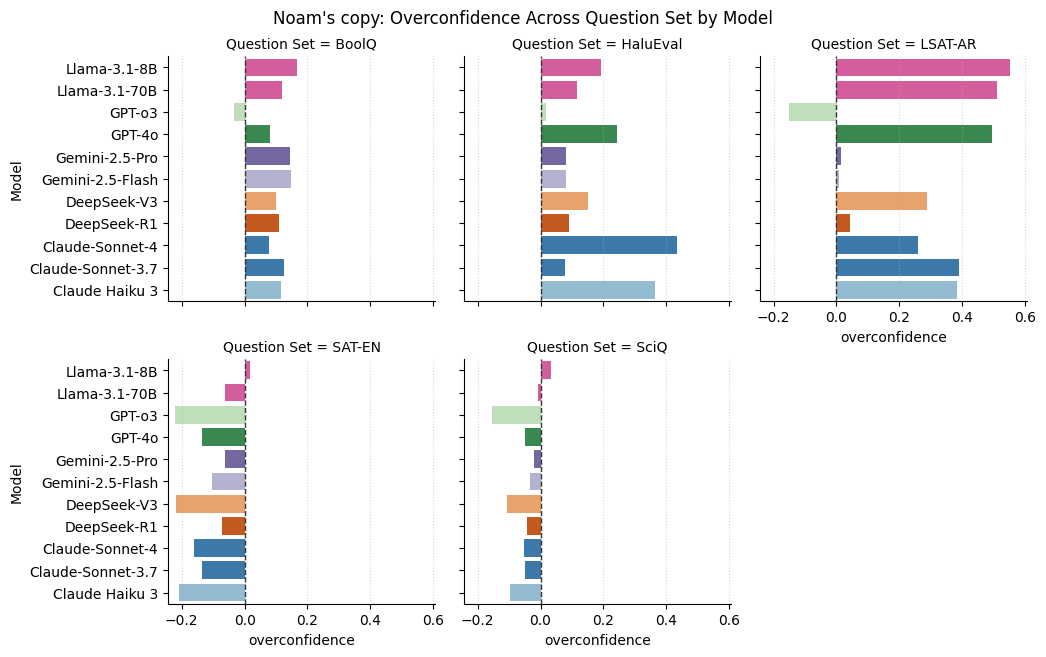

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df has columns: "Question Set", "Model", "Overconfidence"
d = sum_df.copy()#.sort_values("Model", ascending = True)
model_order = ['Llama-3.1-8B', # Same order as Jacob
 'Llama-3.1-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude Haiku 3'] 

palette = {m: pick_color(m) for m in sorted(d["Model"].unique(), key=str.lower)}

g = sns.catplot(
    data=d, kind="bar",
    x="Overconfidence", y="Model",
    col="Question Set", col_wrap=3,
    order=model_order, hue = "Model",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = min(-0.05, d["Overconfidence"].min()*1.1)
xmax = max( 0.05, d["Overconfidence"].max()*1.1)
g.set(xlim=(xmin, xmax), xlabel="overconfidence", ylabel="Model")

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
g.fig.suptitle("Noam's copy: Overconfidence Across Question Set by Model", y = 1.02)
plt.show()


In [22]:
d

,Question Set,Model,Accuracy,ECE,Confidence,Overconfidence
0,BoolQ,Claude-Sonnet-3.7,0.831402,0.124338,0.955741,0.124338
1,BoolQ,Claude Haiku 3,0.781462,0.117527,0.897631,0.116169
2,BoolQ,Claude-Sonnet-4,0.842988,0.080100,0.919732,0.076744
3,BoolQ,DeepSeek-R1,0.844986,0.111075,0.956061,0.111075
4,BoolQ,DeepSeek-V3,0.829005,0.102217,0.929425,0.100419
5,BoolQ,Gemini-2.5-Flash,0.845386,0.147651,0.993036,0.147651
6,BoolQ,Gemini-2.5-Pro,0.848981,0.145310,0.993492,0.144511
7,BoolQ,GPT-4o,0.852976,0.079920,0.932577,0.079600
8,BoolQ,GPT-o3,0.860567,0.044027,0.825905,-0.034662
9,BoolQ,Llama-3.1-70B,0.785857,0.124427,0.906009,0.120152


/tmp/ipykernel_1242742/893778821.py:7: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  j["qset"] = pd.Categorical(j["qset"], categories=qset_order, ordered=True)


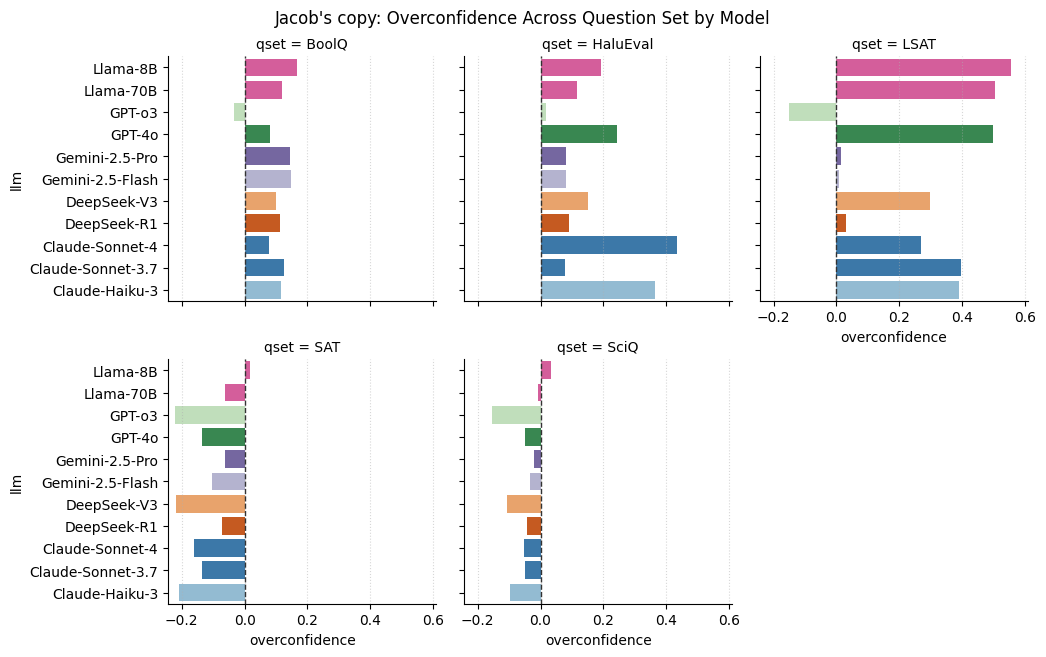

In [23]:
##
## Jacob's Version:

j = pd.read_csv(r"MISC/table1-info.csv")

qset_order = ["BoolQ", "HaluEval", "LSAT", "SAT", "SciQ"]  # edit as needed
j["qset"] = pd.Categorical(j["qset"], categories=qset_order, ordered=True)

model_order = ['Llama-8B', # Same order as Jacob
 'Llama-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude-Haiku-3'] 

palette = {m: pick_color(m) for m in sorted(j["llm"].unique(), key=str.lower)}

g = sns.catplot(
    data=j, kind="bar",
    x="overconfidence", y="llm",
    col="qset", col_wrap=3,
    order=model_order, hue = "llm",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = min(-0.05, j["overconfidence"].min()*1.1)
xmax = max( 0.05, j["overconfidence"].max()*1.1)
g.set(xlim=(xmin, xmax), xlabel="overconfidence", ylabel="llm")

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
g.figure.suptitle("Jacob's copy: Overconfidence Across Question Set by Model", y = 1.02)
plt.show()

,Question Set,Model,Accuracy,ECE,Confidence,Overconfidence,name,qset,llm,num_tot,ece,accuracy,confidence,avg_gini,overconfidence,diff
18,LSAT-AR,DeepSeek-R1,0.953488,0.046047,0.997209,0.043721,LSAT-ARDeepSeek-R1,LSAT-AR,DeepSeek-R1,87,0.034023,0.965517,0.997241,0.005277,0.031724,0.011997


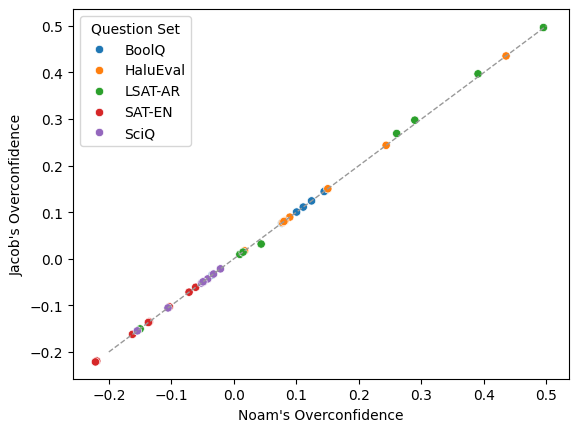

In [24]:
j['qset'] = j['qset'].cat.rename_categories({"LSAT": "LSAT-AR", "SAT": "SAT-EN"})

j['name'] = j['qset'].astype(str) + j['llm'].astype(str) 
d['name'] = d['Question Set'] + d['Model']

merged = pd.merge(d,j , on = "name", suffixes= ['_noam', '_jacob'])
merged['diff'] = merged['Overconfidence'] - merged['overconfidence']

display(merged[abs(merged['diff']) > 0.01]) # These are all the instances where Jacob and I disagree (some very small differences exist due to FPA)

ax = sns.scatterplot(data = merged, x ="Overconfidence", y = "overconfidence", hue = "Question Set")
plt.xlabel("Noam's Overconfidence")
plt.ylabel("Jacob's Overconfidence")
lo = -0.2
hi = 0.5
ax.plot([lo, hi], [lo, hi], ls="--", c="0.6", lw=1) 
plt.show()


---
## ECE Plots


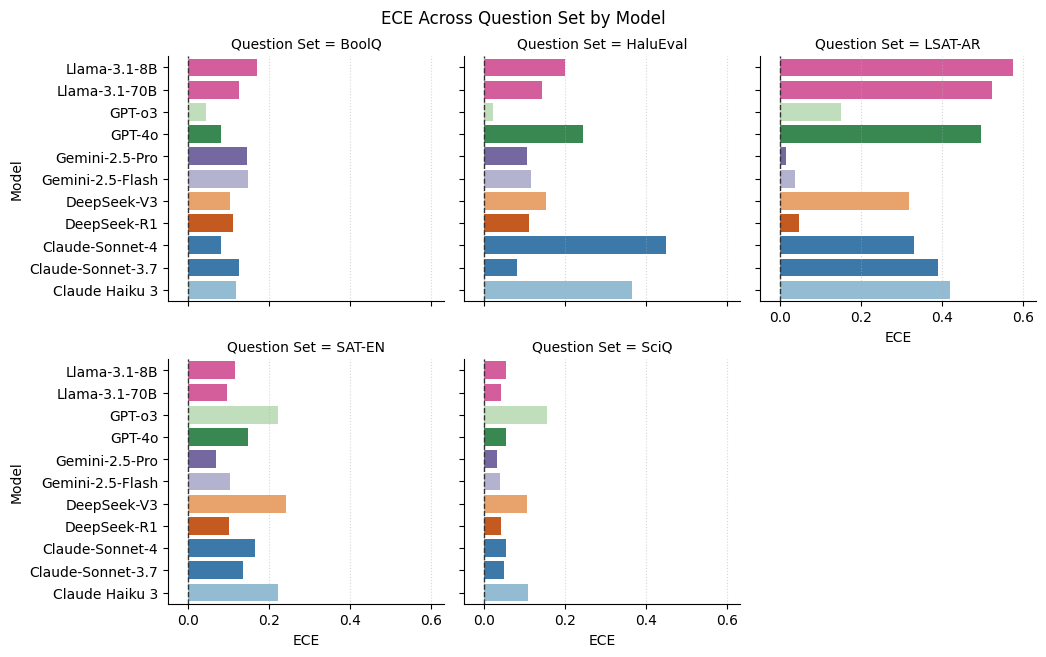

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df has columns: "Question Set", "Model", "Overconfidence"
d = sum_df.copy()#.sort_values("Model", ascending = True)
model_order = ['Llama-3.1-8B', # Same order as Jacob
 'Llama-3.1-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude Haiku 3'] 

palette = {m: pick_color(m) for m in sorted(d["Model"].unique(), key=str.lower)}

g = sns.catplot(
    data=d, kind="bar",
    x="ECE", y="Model",
    col="Question Set", col_wrap=3,
    order=model_order, hue = "Model",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = min(-0.05, d["ECE"].min()*1.1)
xmax = max( 0.05, d["ECE"].max()*1.1)
g.set(xlim=(xmin, xmax), xlabel="ECE", ylabel="Model")

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
g.figure.suptitle("ECE Across Question Set by Model", y = 1.02)
plt.show()

/tmp/ipykernel_1242742/3267734631.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  j["qset"] = pd.Categorical(j["qset"], categories=qset_order, ordered=True)


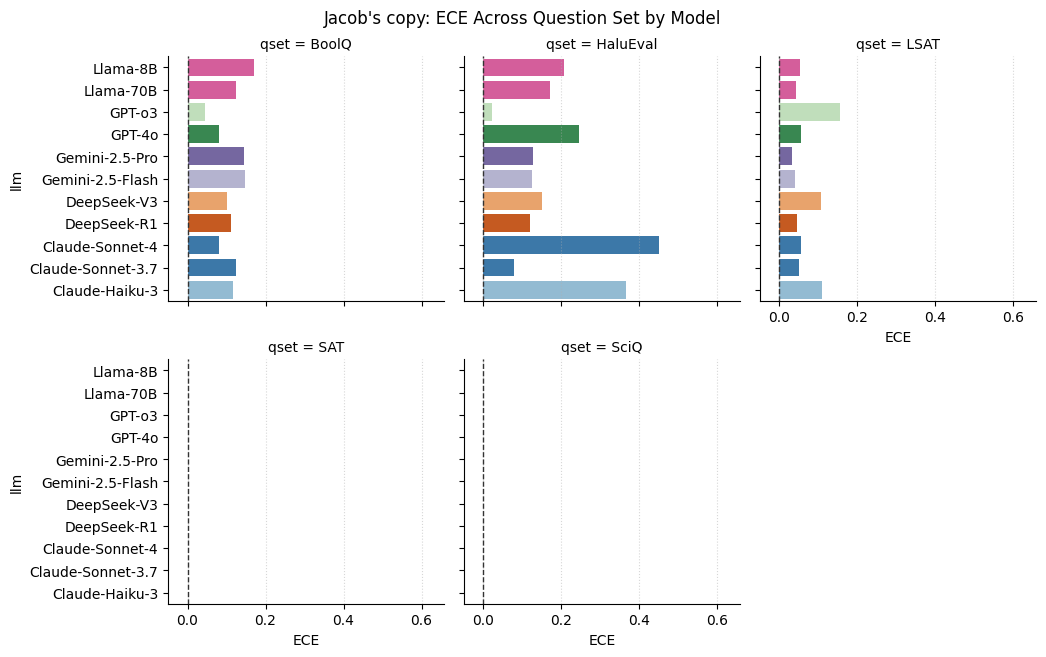

In [26]:
##
## Jacob's Version:

qset_order = ["BoolQ", "HaluEval", "LSAT", "SAT", "SciQ"]  # edit as needed
j["qset"] = pd.Categorical(j["qset"], categories=qset_order, ordered=True)

model_order = ['Llama-8B', # Same order as Jacob
 'Llama-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude-Haiku-3'] 

palette = {m: pick_color(m) for m in sorted(j["llm"].unique(), key=str.lower)}

g = sns.catplot(
    data=j, kind="bar",
    x="ece", y="llm",
    col="qset", col_wrap=3,
    order=model_order, hue = "llm",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = min(-0.05, j["ece"].min()*1.1)
xmax = max( 0.05, j["ece"].max()*1.1)
g.set(xlim=(xmin, xmax), xlabel="ECE", ylabel="llm")

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
g.fig.suptitle("Jacob's copy: ECE Across Question Set by Model", y = 1.02)
plt.show()

Lets see how well they line up like before:

,Question Set,Model,Accuracy,ECE,Confidence,Overconfidence,name,qset,llm,num_tot,ece,accuracy,confidence,avg_gini,overconfidence,diff
12,HaluEval,Gemini-2.5-Flash,0.521229,0.114547,0.602872,0.081642,HaluEvalGemini-2.5-Flash,HaluEval,Gemini-2.5-Flash,1790,0.125721,0.521229,0.602872,NaN,0.081642,-0.011173
13,HaluEval,Gemini-2.5-Pro,0.521229,0.105503,0.601369,0.080140,HaluEvalGemini-2.5-Pro,HaluEval,Gemini-2.5-Pro,1790,0.126732,0.521229,0.601369,NaN,0.080140,-0.021229


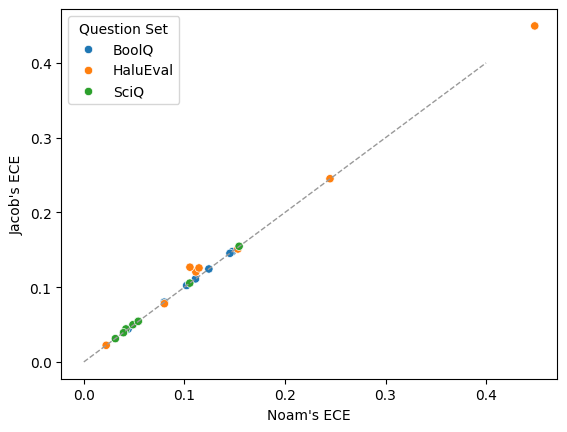

In [27]:
j['qset'] = j['qset'].cat.rename_categories({"LSAT": "LSAT-AR", "SAT": "SAT-EN"})

j['name'] = j['qset'].astype(str) + j['llm'].astype(str) 
d['name'] = d['Question Set'] + d['Model']

merged = pd.merge(d,j ,on = "name", suffixes= ['_noam', '_jacob'])
merged['diff'] = merged['ECE'] - merged['ece']

display(merged[abs(merged['diff']) > 0.01]) # These are all the instances where Jacob and I disagree (some very small differences exist due to FPA)

ax = sns.scatterplot(data = merged, x ="ECE", y = "ece", hue = "Question Set")
plt.xlabel("Noam's ECE")
plt.ylabel("Jacob's ECE")
lo = 0.0
hi = 0.4
ax.plot([lo, hi], [lo, hi], ls="--", c="0.6", lw=1) 
plt.show()


In [28]:
(combined_clean["Answer"] == "E").sum()

np.int64(156)

In [29]:
combined_clean["Answer"].value_counts().head(10)

Answer
True     14347
False    13186
D         3654
A         3650
B         3206
C         3128
E          156
Name: count, dtype: int64

Although we have the same average confidence and accuracy for HaluEval, we differ on ECE scores. I wonder why?

I always inlcude the lowest value (e.g. [0.1, 0.2)

It seems that Jacob uses `confidence_bin = cut(stated_confidence, breaks = 10)` in order to slice up the bins. I think in my implementation I added an additional bin for [1.0] leading to 11 bins while Jacob has 10. This may be the reason for differing results when looking at ECE.

# Pre-Registered Analysis

* For each model/question set combination we will compute ECE and overconfidence. We will test whether they differ from zero for each model and in aggregate.
* In addition, we will build  a calibration plot. The calibration plot will be designed as follows: Confidence (stated or token)  along the x-axis and accuracy on the y-axis. The analysis is at the level of the bin, which is to say for multiple-choice questions with 4 answer options, there will be 4 observations. Answer options are binned according to the probability assigned to them by the LLM. The 11 bins are: [0-10), [10-20), [20-30), [30-40), [40-50), [50-60), [60-70), [70-80), [80-90), [90-100), [100]
* For each of the 11 bins, we average the confidence of observations within it, and that determines where the dot is placed on the horizontal axis. We then average the accuracy of those responses (what percentage of the time is that answer option the right one?) and that accuracy determines the dot's location on the y-axis.

## ECE Plots

First we can look at how each model did on each question set individually:

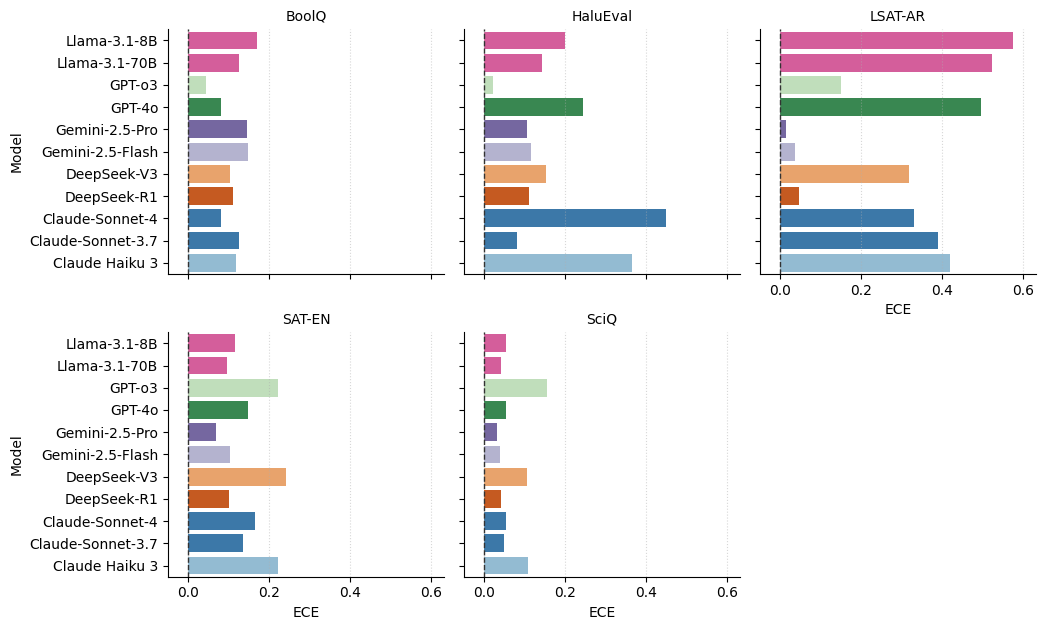

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df has columns: "Question Set", "Model", "Overconfidence"
d = sum_df.copy()#.sort_values("Model", ascending = True)
model_order = ['Llama-3.1-8B', # Same order as Jacob
 'Llama-3.1-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude Haiku 3'] 

palette = {m: pick_color(m) for m in sorted(d["Model"].unique(), key=str.lower)}

g = sns.catplot(
    data=d, kind="bar",
    x="ECE", y="Model",
    col="Question Set", col_wrap=3,
    order=model_order, hue = "Model",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = min(-0.05, d["ECE"].min()*1.1)
xmax = max( 0.05, d["ECE"].max()*1.1)
g.set(xlim=(xmin, xmax), xlabel="ECE", ylabel="Model")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
#g.figure.suptitle("ECE Across Question Set by Model", y = 1.02)
plt.show()

Now, lets see how models did in agregate:

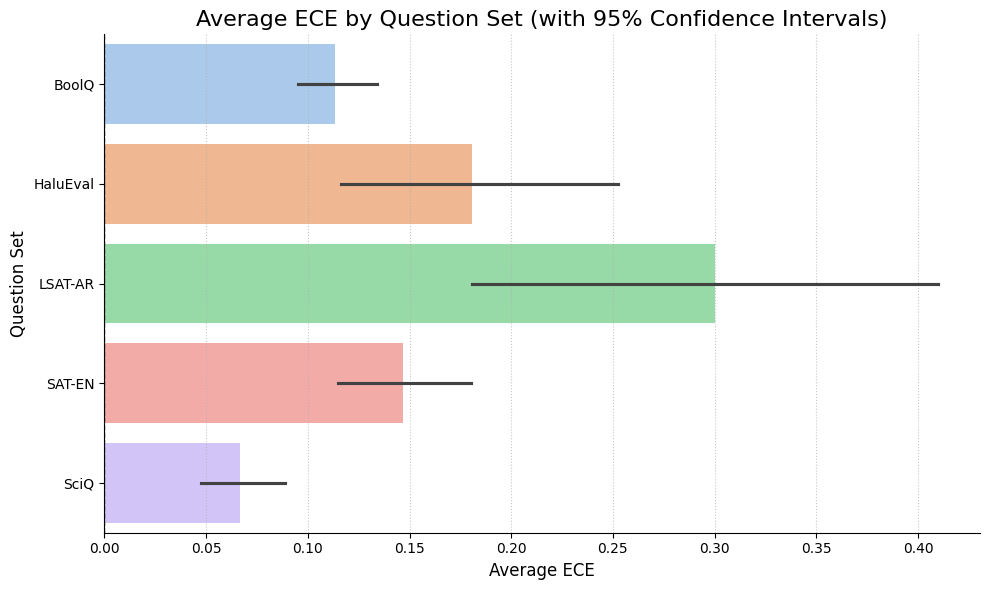

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'd' is your original DataFrame with ECE values 
# for each model and question set.

# 1. Determine the sorted order for the plot
# We do this by calculating the mean ECE for each set and sorting them,
# Doing so alphabetically
order_of_sets = d.groupby('Question Set')['Question Set'].unique().sort_values(ascending=True).index

# 2. Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=d,             # *** Pass the original DataFrame 'd' ***
    x='ECE',
    y='Question Set',
    hue = "Question Set",
    order=order_of_sets, # Apply the sorted order
    palette='pastel'
    # Seaborn automatically calculates the mean and 95% confidence
    # interval (the error bars) when you pass the full data.
)

# Set labels and title
ax.set_title('Average ECE by Question Set (with 95% Confidence Intervals)', fontsize=16)
ax.set_xlabel('Average ECE', fontsize=12)
ax.set_ylabel('Question Set', fontsize=12)

# Add gridlines and clean up spines, similar to your original plot
ax.grid(True, axis='x', linestyle=':', alpha=0.7)
ax.axvline(0, linestyle="--", linewidth=1, color="0.2") # Add the zero line
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

## Overconfidence Plots

Like before, we can first compare how overconfident models were individually.

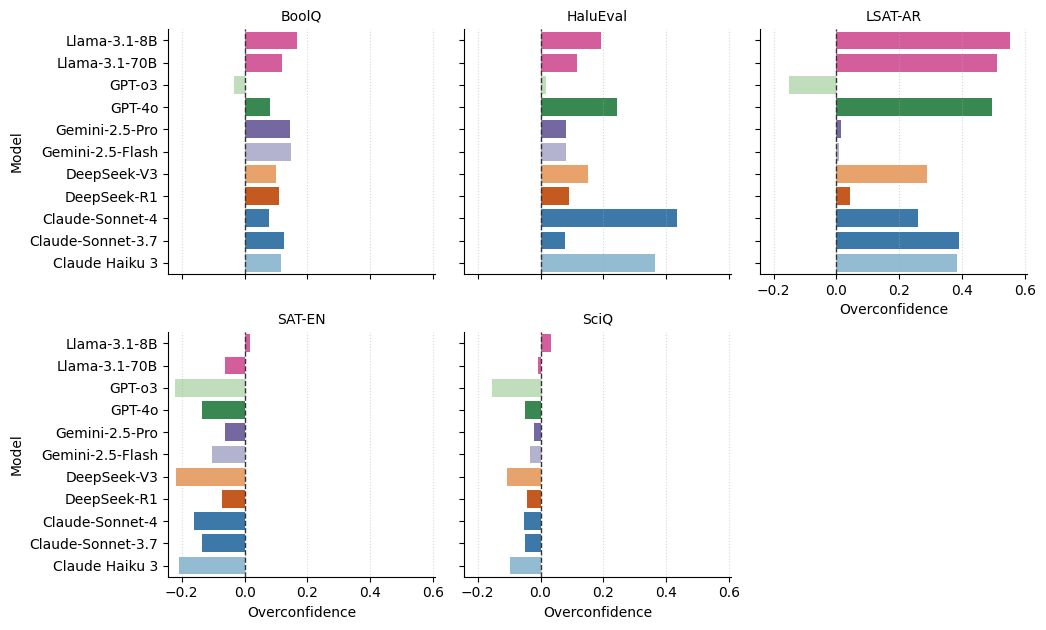

In [32]:
# df has columns: "Question Set", "Model", "Overconfidence"
d = sum_df.copy()#.sort_values("Model", ascending = True)
model_order = ['Llama-3.1-8B', # Same order as Jacob
 'Llama-3.1-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude Haiku 3'] 

palette = {m: pick_color(m) for m in sorted(d["Model"].unique(), key=str.lower)}

g = sns.catplot(
    data=d, kind="bar",
    x="Overconfidence", y="Model",
    col="Question Set", col_wrap=3,
    order=model_order, hue = "Model",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = min(-0.05, d["Overconfidence"].min()*1.1)
xmax = max( 0.05, d["Overconfidence"].max()*1.1)
g.set(xlim=(xmin, xmax), xlabel="Overconfidence", ylabel="Model")
g.set_titles(col_template="{col_name}")


for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
#g.figure.suptitle("Overconfidence Across Question Set by Model", y = 1.02)
plt.show()


And again, lets see how models did in agregate:


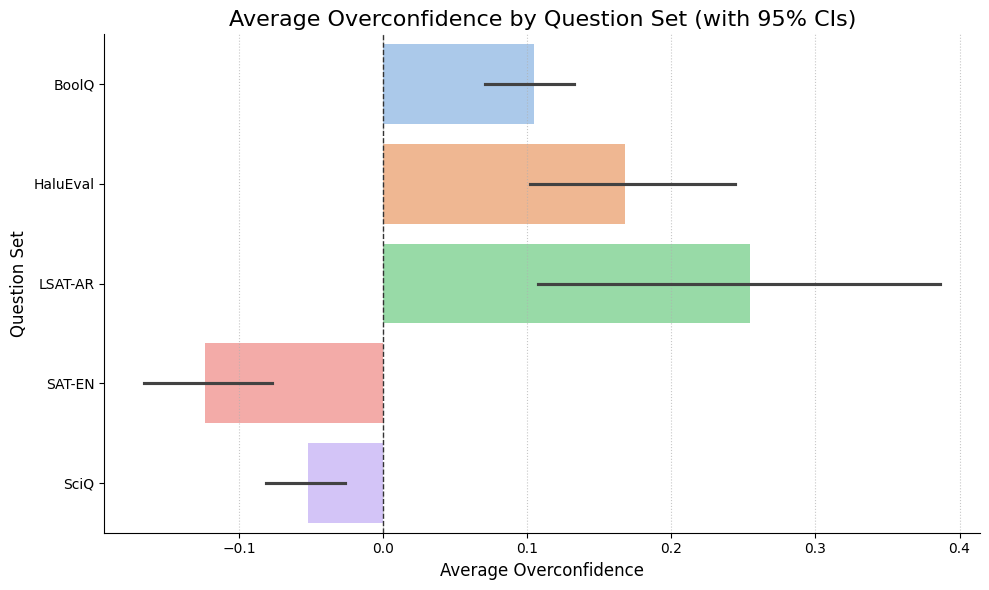

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'd' is your DataFrame with "Overconfidence", "Model", 
# and "Question Set" columns.

# 1. Determine the sorted order for the plot
# We sort by the mean overconfidence for each question set.
overconfidence_order = d.groupby('Question Set')['Overconfidence'].mean().sort_values(ascending=False).index
order_of_sets = d.groupby('Question Set')['Question Set'].unique().sort_values(ascending=True).index

# 2. Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=d,                  # *** Pass the original DataFrame 'd' ***
    x='Overconfidence',      # *** Plot the 'Overconfidence' column ***
    y='Question Set',
    order=order_of_sets, # Apply the sorted order
    hue = "Question Set",
    palette='pastel'         # Switched palette for variety (cool colors)
)

# Set labels and title
ax.set_title('Average Overconfidence by Question Set (with 95% CIs)', fontsize=16)
ax.set_xlabel('Average Overconfidence', fontsize=12)
ax.set_ylabel('Question Set', fontsize=12)

# Add gridlines and clean up spines
ax.grid(True, axis='x', linestyle=':', alpha=0.7)
ax.axvline(0, linestyle="--", linewidth=1, color="0.2") # Add the zero line
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

## Accuracy Plots

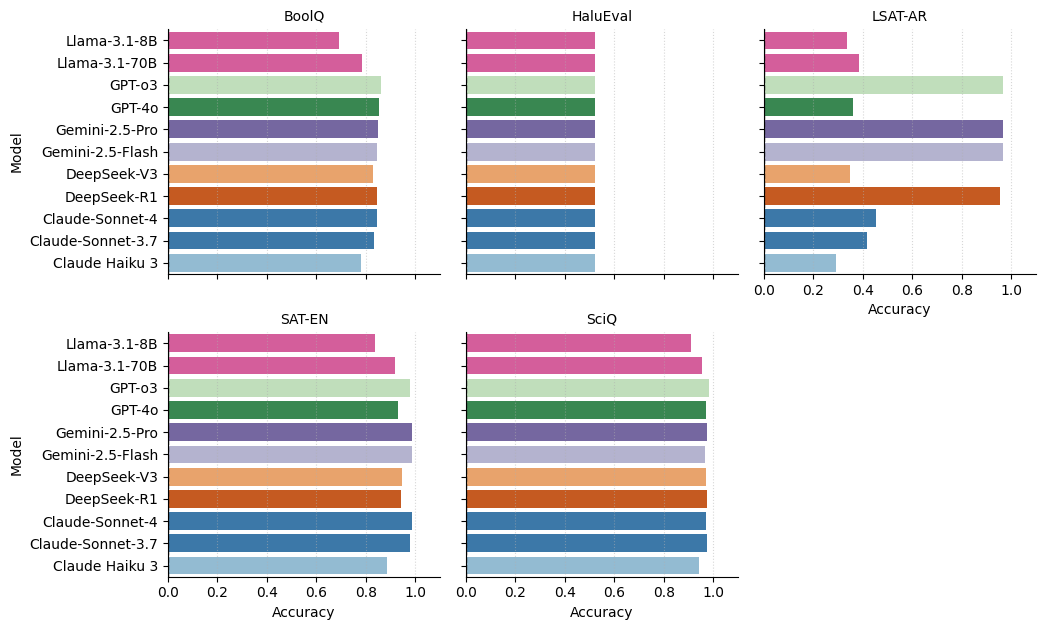

In [34]:
# df has columns: "Question Set", "Model", "Overconfidence"
d = sum_df.copy()#.sort_values("Model", ascending = True)
model_order = ['Llama-3.1-8B', # Same order as Jacob
 'Llama-3.1-70B',
 'GPT-o3',
 'GPT-4o',
 'Gemini-2.5-Pro',
 'Gemini-2.5-Flash',
 'DeepSeek-V3',
 'DeepSeek-R1',
 'Claude-Sonnet-4',
 'Claude-Sonnet-3.7',
 'Claude Haiku 3'] 

palette = {m: pick_color(m) for m in sorted(d["Model"].unique(), key=str.lower)}

g = sns.catplot(
    data=d, kind="bar",
    x="Accuracy", y="Model",
    col="Question Set", col_wrap=3,
    order=model_order, hue = "Model",
    palette = palette,
    height=3.2, aspect=1.1,# edgecolor="0.0"
)

xmin = 0
xmax = 1.1
g.set(xlim=(xmin, xmax), xlabel="Accuracy", ylabel="Model")
g.set_titles(col_template="{col_name}")


for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", linewidth=1, color="0.2")
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
#g.figure.suptitle("Accuracy Across Question Set by Model", y = 1.02)
plt.show()


In [35]:
lsat = d[d['Question Set'] == 'LSAT-AR']
lsat['Accuracy'].value_counts()

Accuracy
0.965116    3
0.418605    1
0.290698    1
0.453488    1
0.953488    1
0.348837    1
0.360465    1
0.383721    1
0.337209    1
Name: count, dtype: int64

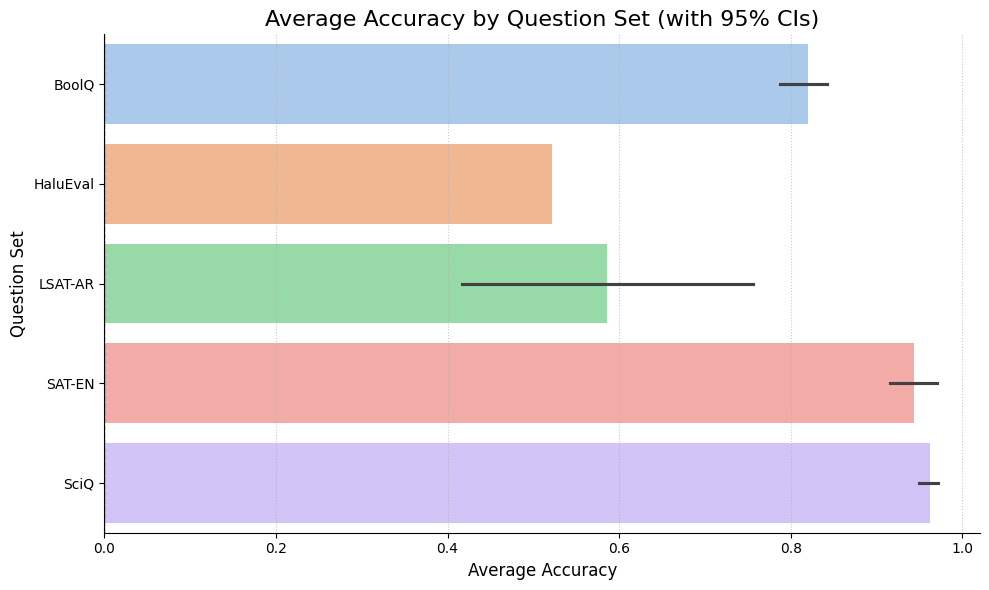

In [36]:


# 1. Determine the sorted order for the plot
# We sort by the mean overconfidence for each question set.
overconfidence_order = d.groupby('Question Set')['Accuracy'].mean().sort_values(ascending=False).index
order_of_sets = d.groupby('Question Set')['Question Set'].unique().sort_values(ascending=True).index

# 2. Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=d,                  # *** Pass the original DataFrame 'd' ***
    x='Accuracy',      # *** Plot the 'Overconfidence' column ***
    y='Question Set',
    order=order_of_sets, # Apply the sorted order
    hue = "Question Set",
    palette='pastel'         # Switched palette for variety (cool colors)
)

# Set labels and title
ax.set_title('Average Accuracy by Question Set (with 95% CIs)', fontsize=16)
ax.set_xlabel('Average Accuracy', fontsize=12)
ax.set_ylabel('Question Set', fontsize=12)

# Add gridlines and clean up spines
ax.grid(True, axis='x', linestyle=':', alpha=0.7)
ax.axvline(0, linestyle="--", linewidth=1, color="0.2") # Add the zero line
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
lsat = d[d['Question Set'] == 'LSAT-AR']
lsat.Accuracy#.mean()

22    0.418605
23    0.290698
24    0.453488
25    0.953488
26    0.348837
27    0.965116
28    0.965116
29    0.360465
30    0.965116
31    0.383721
32    0.337209
Name: Accuracy, dtype: float64

## Calibration Plots

Individual Calibration plots can be found in the `Plots` folder. We want to see how models did in agregate.

In [38]:
combined_clean

,Reasoning,Answer,Stated Confidence Answer,Coerce,Content,Question ID,Model,Model Type,Question Set,Score,...,Stated Confidence Answer (MCQ),Token Probability True,Token Probability False,Token Probability Answer,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E,combined_name
0,The question is asking whether the production ...,False,0.60,True,"{\n ""Reasoning"": ""The question is asking wh...",0,Claude-Sonnet-3.7,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0_BoolQ
1,This question is asking about phantom limb pai...,True,0.95,True,"{\n ""Reasoning"": ""This question is asking a...",2,Claude-Sonnet-3.7,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2_BoolQ
2,Harry Potter and the Escape from Gringotts is ...,True,0.98,True,"{\n ""Reasoning"": ""Harry Potter and the Esca...",3,Claude-Sonnet-3.7,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3_BoolQ
3,Hydroxyzine HCl (hydrochloride) and hydroxyzin...,True,0.98,True,"{\n ""Reasoning"": ""Hydroxyzine HCl (hydrochl...",4,Claude-Sonnet-3.7,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4_BoolQ
4,Barq's Root Beer is not a Pepsi product. It is...,False,0.98,True,"{\n ""Reasoning"": ""Barq's Root Beer is not a...",5,Claude-Sonnet-3.7,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5_BoolQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61012,Predation is a biological process where one sp...,A,NaN,True,"{\n""Reasoning"": ""Predation is a biological pro...",995,Llama-3.1-8B,Llama,SciQ,1.0,...,0.95,NaN,NaN,NaN,0.999986,0.000003,0.000001,9.645942e-06,NaN,995_SciQ
61013,Short period comets are thought to originate f...,A,NaN,True,"{\n""Reasoning"": ""Short period comets are thoug...",996,Llama-3.1-8B,Llama,SciQ,1.0,...,0.95,NaN,NaN,NaN,0.999989,0.000004,0.000004,2.966547e-06,NaN,996_SciQ
61014,The question is asking about the developmental...,D,NaN,True,"{\n""Reasoning"": ""The question is asking about ...",997,Llama-3.1-8B,Llama,SciQ,1.0,...,1.00,NaN,NaN,NaN,0.000175,0.000042,0.000043,9.997405e-01,NaN,997_SciQ
61015,Atoms with unstable nuclei are those that have...,D,NaN,True,"{\n""Reasoning"": ""Atoms with unstable nuclei ar...",998,Llama-3.1-8B,Llama,SciQ,1.0,...,1.00,NaN,NaN,NaN,0.000015,0.000018,0.000010,9.999572e-01,NaN,998_SciQ


In [39]:
def expand_mcq(df, tokens = False):
    s = []
    c = []


    # Using iterrows correctly now: 'row' is the Series data for the current row
    for index, row in df.iterrows(): 
        # --- 1. Handle the Model's Stated Answer ---
        if row['Question Set'] == 'LSAT-AR':
            letters = ['A', 'B', 'C', 'D', 'E']
        else:
                letters = ['A', 'B', 'C', 'D']
        
        # --- 2. Handle the Other (Unanswered) Options ---
        ca = row['Correct Answer']

        for l in letters:
            # Score is 1 (True) or 0 (False)
            l_score = 1 if l == ca else 0 

            l_conf_col = f"Stated Confidence {l}"
            if tokens:
                l_conf_col =  f"Token Probability {l}"
            l_conf = row[l_conf_col]
            
            # # Check for NaN/missing confidence (e.g., option 'E' in some 4-option questions)
            # if pd.isna(l_conf): # Changed to pd.isna() for clarity/safety
            #     continue

            # FIX 2: Append the new confidence value (l_conf), not the list itself (c)
            s.append(l_score)
            c.append(l_conf) # <-- Corrected: Appending the single confidence value

    
    return s, c

def expand_bool(df, tokens = False):
    s = []
    c = []
    letters = ['True', 'False']

    # Using iterrows correctly now: 'row' is the Series data for the current row
    for index, row in df.iterrows(): 
        # --- 1. Handle the Model's Stated Answer ---
        stated_answer = row['Answer']

        con_str = 'Stated Confidence Answer'
        if tokens:
            con_str = f"Token Probability {stated_answer}"
        stated_answer_confidence = row[con_str]
        stated_answer_score = row['Score']

        s.append(stated_answer_score)
        c.append(stated_answer_confidence)
        
        # --- 2. Handle the Other (Unanswered) Options ---

        not_stated_answer  = stated_answer == False
        not_stated_answer_confidence = 1 - stated_answer_confidence
        not_stated_answer_score = float(stated_answer_score == 0)

        s.append(not_stated_answer_score)
        c.append(not_stated_answer_confidence)

    
    return s, c
    

def melt_series(score, confidence):
    df = pd.DataFrame({'confidence': confidence, 'score': score})
    df = add_confidence_bin(df)
    df['score'] = df['score'].astype('float')
    # Group by confidence and aggregate
    melt_df = df.groupby('bin', observed=False).agg(
        mean_score=('score', 'mean'),
        count=('score', 'size'),
        mean_confidence = ('confidence', 'mean')
    ).reset_index()


    return melt_df


def add_confidence_bin(df: pd.DataFrame, col: str = 'confidence') -> pd.DataFrame:
    # Copy to avoid modifying original
    df = df.copy()

    # Clip confidence to [0, 1]
    df[col] = df[col].clip(0, 1)

    # Define bin edges and labels for 11 equal-width bins
    bins = np.linspace(0, 1, 11)        # edges: 0.0, 0.1, ..., 1.0 (11 edges -> 10 bins)
    # Labels correspond to the left-edge of each bin (0.1, 0.2, ..., 1.0)
    labels = [round(x, 1) for x in bins[0:]]

    # Assign bin label
    df['bin'] = pd.cut(
        df[col],
        bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.000001],
        labels=labels,
        ordered=False,
        right=False,   # include the right edge in the bin
        include_lowest=True
    )

    return df

def calibration_plot(data, conf = 'SC', scores = 'Score', 
                     bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.000001],
                     title = 'Aggregate Calibration Plot for all Confidence Measures\nExtended MCQ and 2AFC Responses',
                     ax = None,
                     legend = True, color = 'black', label = None):
    if ax is None:
        ax = plt.gca()

    global grouped
    sc_df = data.copy()

    sc_df['bin'] = pd.cut(sc_df[conf], bins = bins, right = False)

    # --------- Group sc_df -------------------

    grouped = sc_df.groupby('bin', observed= False)[[conf, scores]].agg(['mean', 'count', 'std'])
    grouped


    sc_out = grouped.loc[:, [
        (scores, 'mean'),
        (conf, 'mean'),
        (scores, 'count'),         
        (scores, 'std')
    ]]

    # rename to desired names
    sc_out.columns = ['mean_score', 'mean_confidence', 'count', 'std']

    # Calculate Confidence Interval
    se = sc_out["std"] / np.sqrt(sc_out["count"])   # standard error per bin
    sc_out["ci"] = 1.96 * se  

    sc_out
    # ________________________ Plotting ----------------------------

    ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    
    ax.axline([0, 0], [1, 1], color='grey', linestyle='--', label='Line of Perfect Calibration', alpha = 0.5)



    ax.errorbar(
        sc_out['mean_confidence'],
        sc_out['mean_score'],
        yerr= sc_out['ci'],  # symmetric CI
        fmt='none',   # no extra markers (we already drew them with seaborn)
        linewidth = 2,
        capsize = 0,
        color = 'lightgrey',
        ecolor = 'lightgrey',
        barsabove = False
    )
    if label:
        dot_label = label
    else:
        dot_label  =  'Stated Confidence'
    sns.scatterplot(sc_out, y = 'mean_score', x = 'mean_confidence', label = dot_label, color = color, zorder = 3, ax = ax)

    ax.grid(True, linestyle='--', alpha=0.35)
    if legend:
        ax.legend(loc='lower right')
    else:
        ax.legend().remove()

    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')

    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, 1.1)

    ax.set_title(title)

    #plt.show()



### Combined Agregate Plot

Issues with the combined calibration plot.

1. Combining three different question types (MCQ, 2AFC, PE)
2. Different question contexts (GK, Logical reasoning, etc.)
3. Sampling from a small biased subset of our models
 

---
Combined Stated Confidence Calibration plot for all models



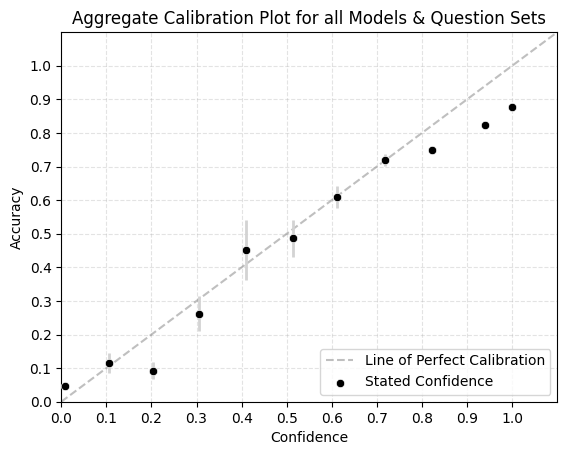

In [40]:
# First plot is with normal treatment of MCQ  and 2AFC (no expansion)
sc_df = combined_clean[['Model', 'Question Set', 'Stated Confidence Answer', 'Stated Confidence Answer (MCQ)', 'Score']].copy()

sc_df['Stated Confidence Answer'] = pd.to_numeric(sc_df['Stated Confidence Answer'], errors='coerce', ).fillna(0)
sc_df['Stated Confidence Answer (MCQ)'] = pd.to_numeric(sc_df['Stated Confidence Answer (MCQ)'], errors='coerce').fillna(0)
# Combine Stated Confidence Answer and Stated Confidence Answer (MCQ) into one (note: there aren't any overrides as no qset has values in both columns)
sc_df['SC'] = np.maximum(sc_df['Stated Confidence Answer'], sc_df['Stated Confidence Answer (MCQ)']) 
calibration_plot(sc_df, title = 'Aggregate Calibration Plot for all Models & Question Sets')

Multiple Choice Questions ['LSAT-AR', 'SAT-EN', 'SciQ']
    Subset Length: 1254.0


Mean Score for Multiple Choice Questions: 0.2457859662877303
2AFC ['BoolQ', 'HaluEval']
    Subset Length: 4293.0


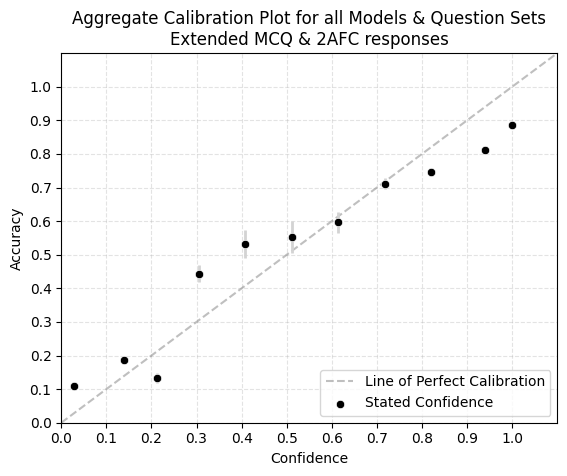

In [41]:
# Extended MCQ

qset_types = {
    "Multiple Choice Questions": ['LSAT-AR', 'SAT-EN', 'SciQ'],
    "2AFC": [ 'BoolQ', 'HaluEval'], # 
}

agg_score = []
agg_conf = []

sc_data = {}

for qtype, qsets in qset_types.items():
    print(qtype, qsets)
    subset = combined_clean[combined_clean['Question Set'].isin(qsets)]
    print(f"    Subset Length: {len(subset) / 11}")
    title = f"Agregate Performance on {qtype} tasks"

    if qtype == "Multiple Choice Questions":
        scores, conf = expand_mcq(subset)
        print(f"Mean Score for {qtype}: {np.mean(scores)}")
        #print(s.mean(), c.mean())
    elif qtype == "2AFC":
        scores, conf = expand_bool(subset)


    sc_data[qtype] = {
        "Score": scores,
        "Conf": conf
    }
    agg_score.extend(scores)
    agg_conf.extend(conf)

sc_df = pd.DataFrame({
    "Score": agg_score,
    "SC": agg_conf
})

sc_df['SC'] = sc_df['SC'].astype(float)

calibration_plot(sc_df, title = 'Aggregate Calibration Plot for all Models & Question Sets\nExtended MCQ & 2AFC responses')

**NOTE**: Although this is an agregate plot, we still see that at the $50\%$ confidence levels. Accuracy ranges from below $30\%$ to nearly $70\%$

Multiple Choice Questions ['LSAT-AR', 'SAT-EN', 'SciQ']
    Subset Length: 1254.0


Mean Score for Multiple Choice Questions: 0.2457859662877303
2AFC ['BoolQ', 'HaluEval']
    Subset Length: 4293.0


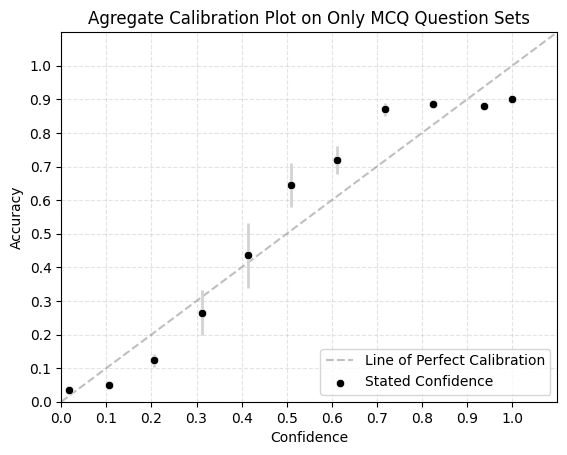

In [42]:
# Lets see only MCQ


# Extended MCQ

qset_types = {
    "Multiple Choice Questions": ['LSAT-AR', 'SAT-EN', 'SciQ'],
    "2AFC": ['BoolQ', 'HaluEval'],
}

agg_score = []
agg_conf = []

sc_data = {}

for qtype, qsets in qset_types.items():
    print(qtype, qsets)
    subset = combined_clean[combined_clean['Question Set'].isin(qsets)]
    print(f"    Subset Length: {len(subset) / 11}")
    title = f"Agregate Performance on {qtype} tasks"
    if qtype == "Multiple Choice Questions":
        scores, conf = expand_mcq(subset)
        print(f"Mean Score for {qtype}: {np.mean(scores)}")
        #print(s.mean(), c.mean())
    elif qtype == "2AFC":
        continue
        scores, conf = expand_bool(subset)

    else:
        continue
        scores = subset['Score']
        conf = subset['Stated Confidence Answer']

    sc_data[qtype] = {
        "Score": scores,
        "Conf": conf
    }
    agg_score.extend(scores)
    agg_conf.extend(conf)

sc_df = pd.DataFrame({
    "Score": agg_score,
    "SC": agg_conf
})

sc_df['SC'] = sc_df['SC'].astype(float)

calibration_plot(sc_df, title = 'Agregate Calibration Plot on Only MCQ Question Sets')

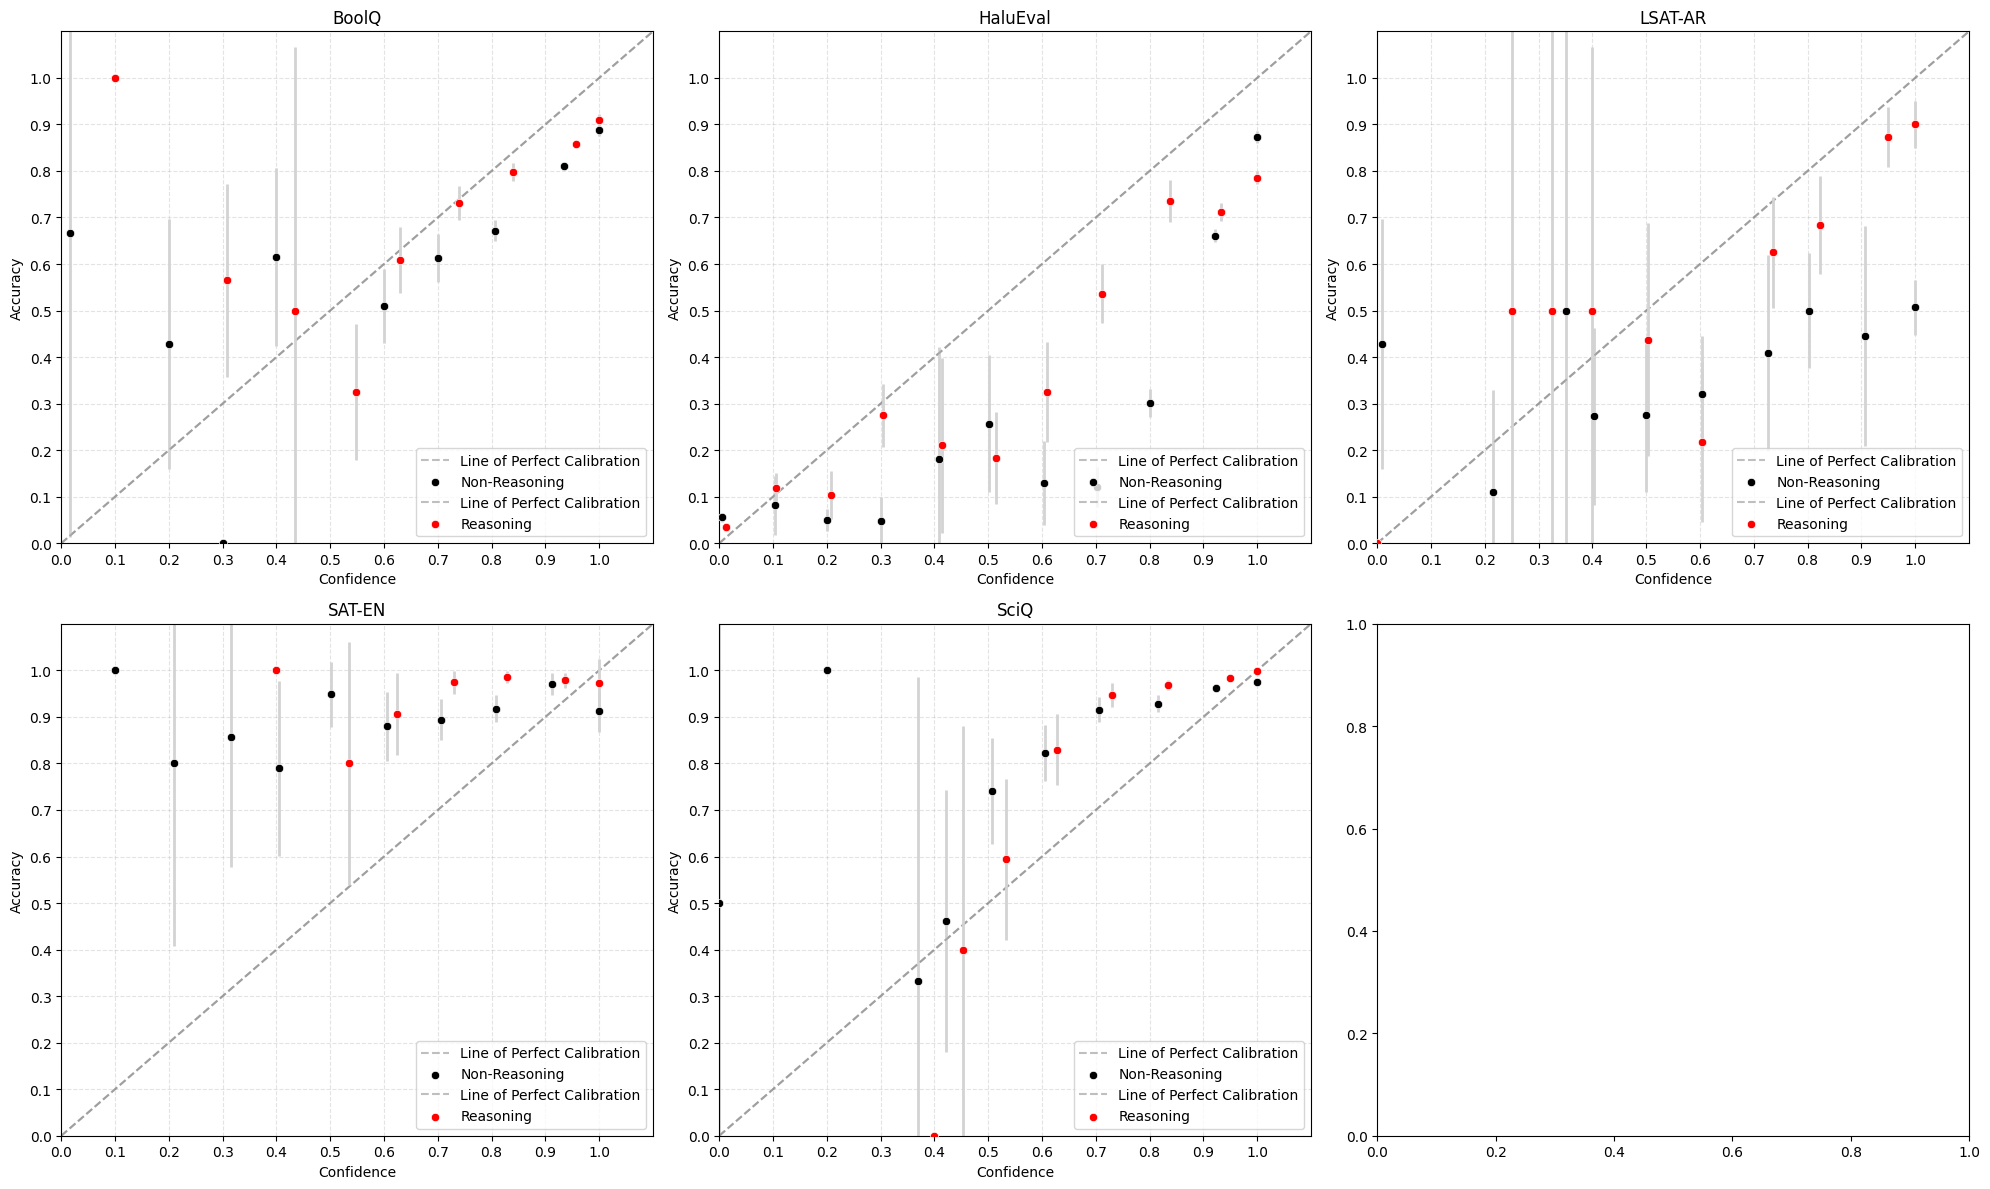

In [43]:
# 1. Setup the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

unique_qsets = combined_clean["Question Set"].unique()
is_reasoning= ['Claude-Sonnet-3.7', 'Claude-Sonnet-4', 'DeepSeek-R1', 'Gemini-2.5-Pro', 'GPT-o3']

for i, special_qset_name in enumerate(unique_qsets):
    if i >= 6: break
    ax = axes_flat[i]
    
    # Filter data for this specific Question Set
    full_qset_df = combined_clean[combined_clean['Question Set'] == special_qset_name].copy()
    
    # Pre-process the Confidence column (SC)
    col = 'Stated Confidence Answer (MCQ)' if special_qset_name in mcq_qsets else 'Stated Confidence Answer'
    full_qset_df['SC'] = pd.to_numeric(full_qset_df[col], errors='coerce').fillna(0)

    # 2. Split into Reasoning vs Non-Reasoning
    reasoning_df = full_qset_df[full_qset_df['Model'].isin(is_reasoning)]
    non_reasoning_df = full_qset_df[~full_qset_df['Model'].isin(is_reasoning)]

    # 3. Plot Non-Reasoning (Black)
    if not non_reasoning_df.empty:
        calibration_plot(non_reasoning_df, title=special_qset_name, 
                         ax=ax, color='black', label='Non-Reasoning', legend=False)

    # 4. Plot Reasoning (Red) - Notice we pass the same 'ax' to overlay them
    if not reasoning_df.empty:
        calibration_plot(reasoning_df, title=special_qset_name, 
                         ax=ax, color='red', label='Reasoning', legend=True)

# Cleanup and Display
plt.tight_layout()
plt.show()

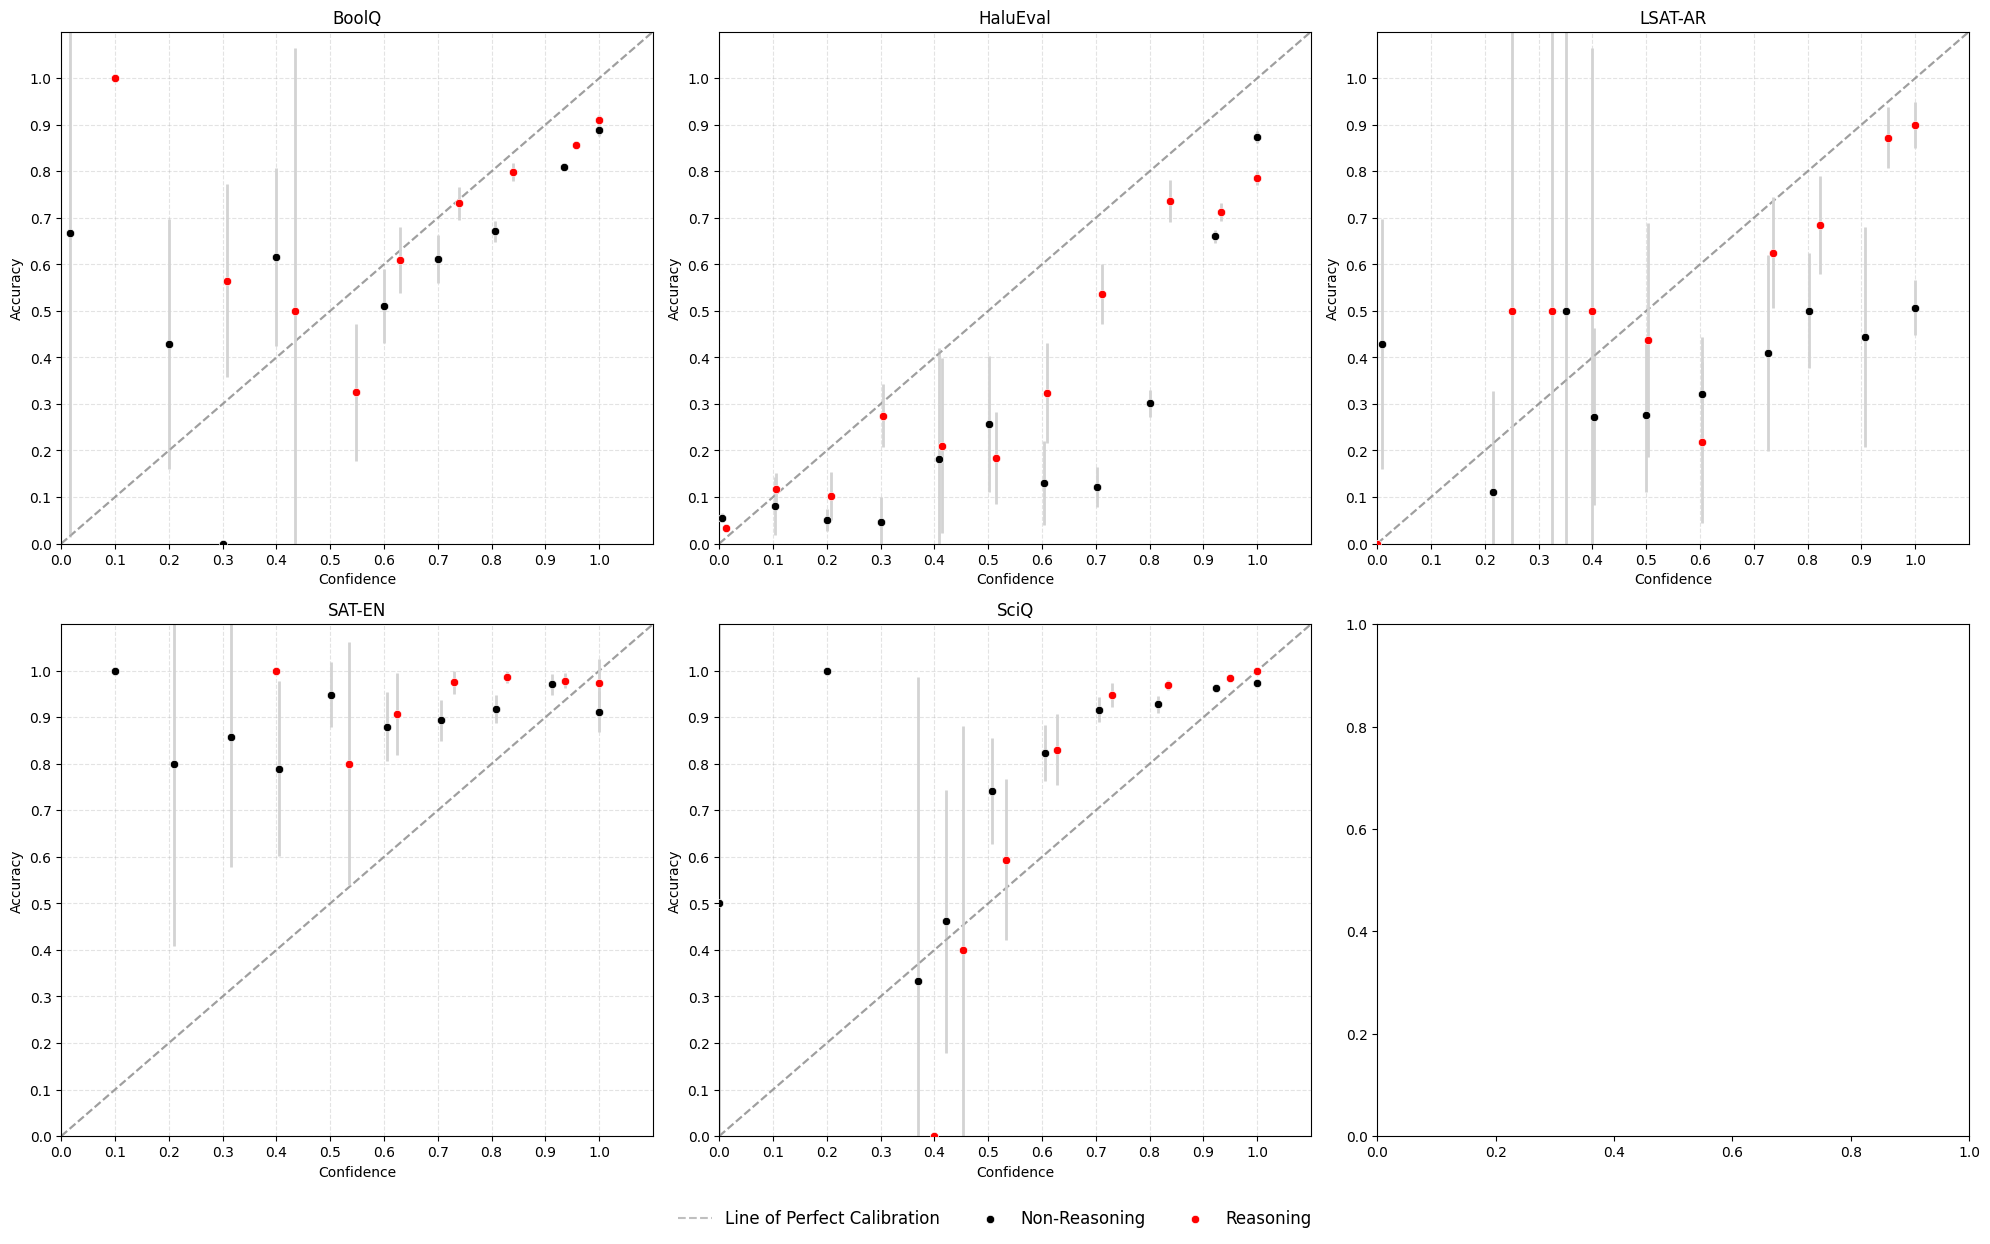

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for i, special_qset_name in enumerate(unique_qsets):
    if i >= 6: break
    ax = axes_flat[i]
    
    full_qset_df = combined_clean[combined_clean['Question Set'] == special_qset_name].copy()
    col = 'Stated Confidence Answer (MCQ)' if special_qset_name in mcq_qsets else 'Stated Confidence Answer'
    full_qset_df['SC'] = pd.to_numeric(full_qset_df[col], errors='coerce').fillna(0)

    reasoning_df = full_qset_df[full_qset_df['Model'].isin(is_reasoning)]
    non_reasoning_df = full_qset_df[~full_qset_df['Model'].isin(is_reasoning)]

    # Plot both (Legend=False inside function)
    calibration_plot(non_reasoning_df, title=special_qset_name, ax=ax, color='black', label='Non-Reasoning')
    calibration_plot(reasoning_df, title=special_qset_name, ax=ax, color='red', label='Reasoning', legend = False)

# --- CREATE THE GLOBAL LEGEND ---
# Get labels from the very last axis
handles, labels = ax.get_legend_handles_labels()
# Filter out duplicates (like the 'Line of Perfect Calibration' showing up twice)
by_label = dict(zip(labels, handles))

fig.legend(by_label.values(), by_label.keys(), 
           loc='upper center', bbox_to_anchor=(0.5, 0.0), 
           ncol=3, fontsize='large', frameon=False)

plt.tight_layout()
plt.show()

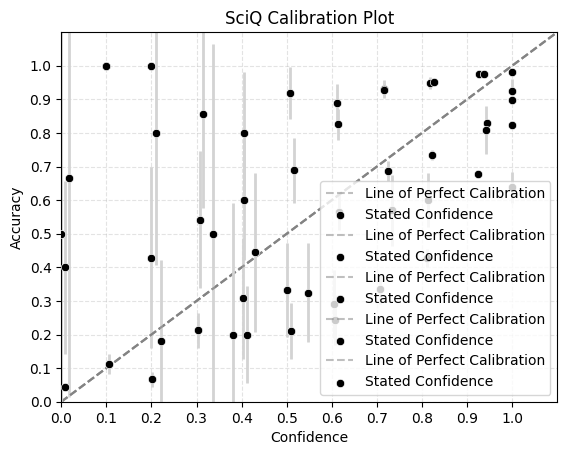

In [45]:
for special_qset_name in combined_clean["Question Set"].unique():

    if special_qset_name in mcq_qsets:
        qset_df = combined_clean[combined_clean['Question Set']== special_qset_name][['Model', 'Question Set', 'Stated Confidence Answer', 'Stated Confidence Answer (MCQ)', 'Score']].copy()


        qset_df['Stated Confidence Answer (MCQ)'] = pd.to_numeric(qset_df['Stated Confidence Answer (MCQ)'], errors='coerce').fillna(0)

        qset_df['SC'] = qset_df['Stated Confidence Answer (MCQ)']

        calibration_plot(qset_df, title = f'{special_qset_name} Calibration Plot')
    else: 
        qset_df = combined_clean[combined_clean['Question Set']== special_qset_name][['Model', 'Question Set', 'Stated Confidence Answer', 'Stated Confidence Answer (MCQ)', 'Score']].copy()

        qset_df['Stated Confidence Answer'] = pd.to_numeric(qset_df['Stated Confidence Answer'], errors='coerce').fillna(0)

        qset_df['SC'] = qset_df['Stated Confidence Answer']

        calibration_plot(qset_df, title = f'{special_qset_name} Calibration Plot')    



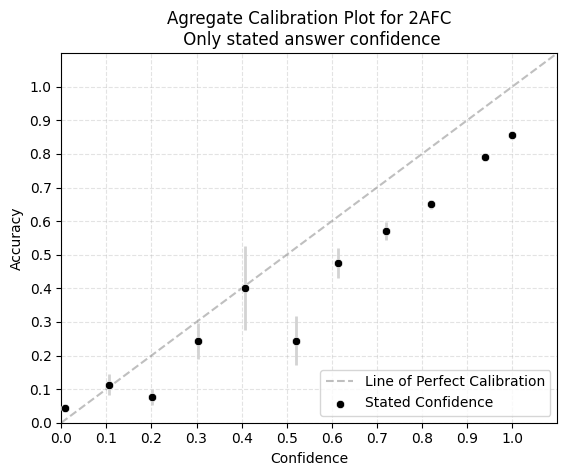

In [46]:
# First plot is with normal treatment of MCQ  and 2AFC (no expansion)
sc_df = combined_clean[combined_clean['Question Set'].isin(['HaluEval', 'BoolQ'])][['Model', 'Question Set', 'Stated Confidence Answer', 'Stated Confidence Answer (MCQ)', 'Score']].copy()


sc_df['Stated Confidence Answer (MCQ)'] = pd.to_numeric(sc_df['Stated Confidence Answer (MCQ)'], errors='coerce').fillna(0)

sc_df['SC'] = sc_df['Stated Confidence Answer']

calibration_plot(sc_df, title = 'Agregate Calibration Plot for 2AFC\n Only stated answer confidence')

### 6 X 11 Calibration Plot

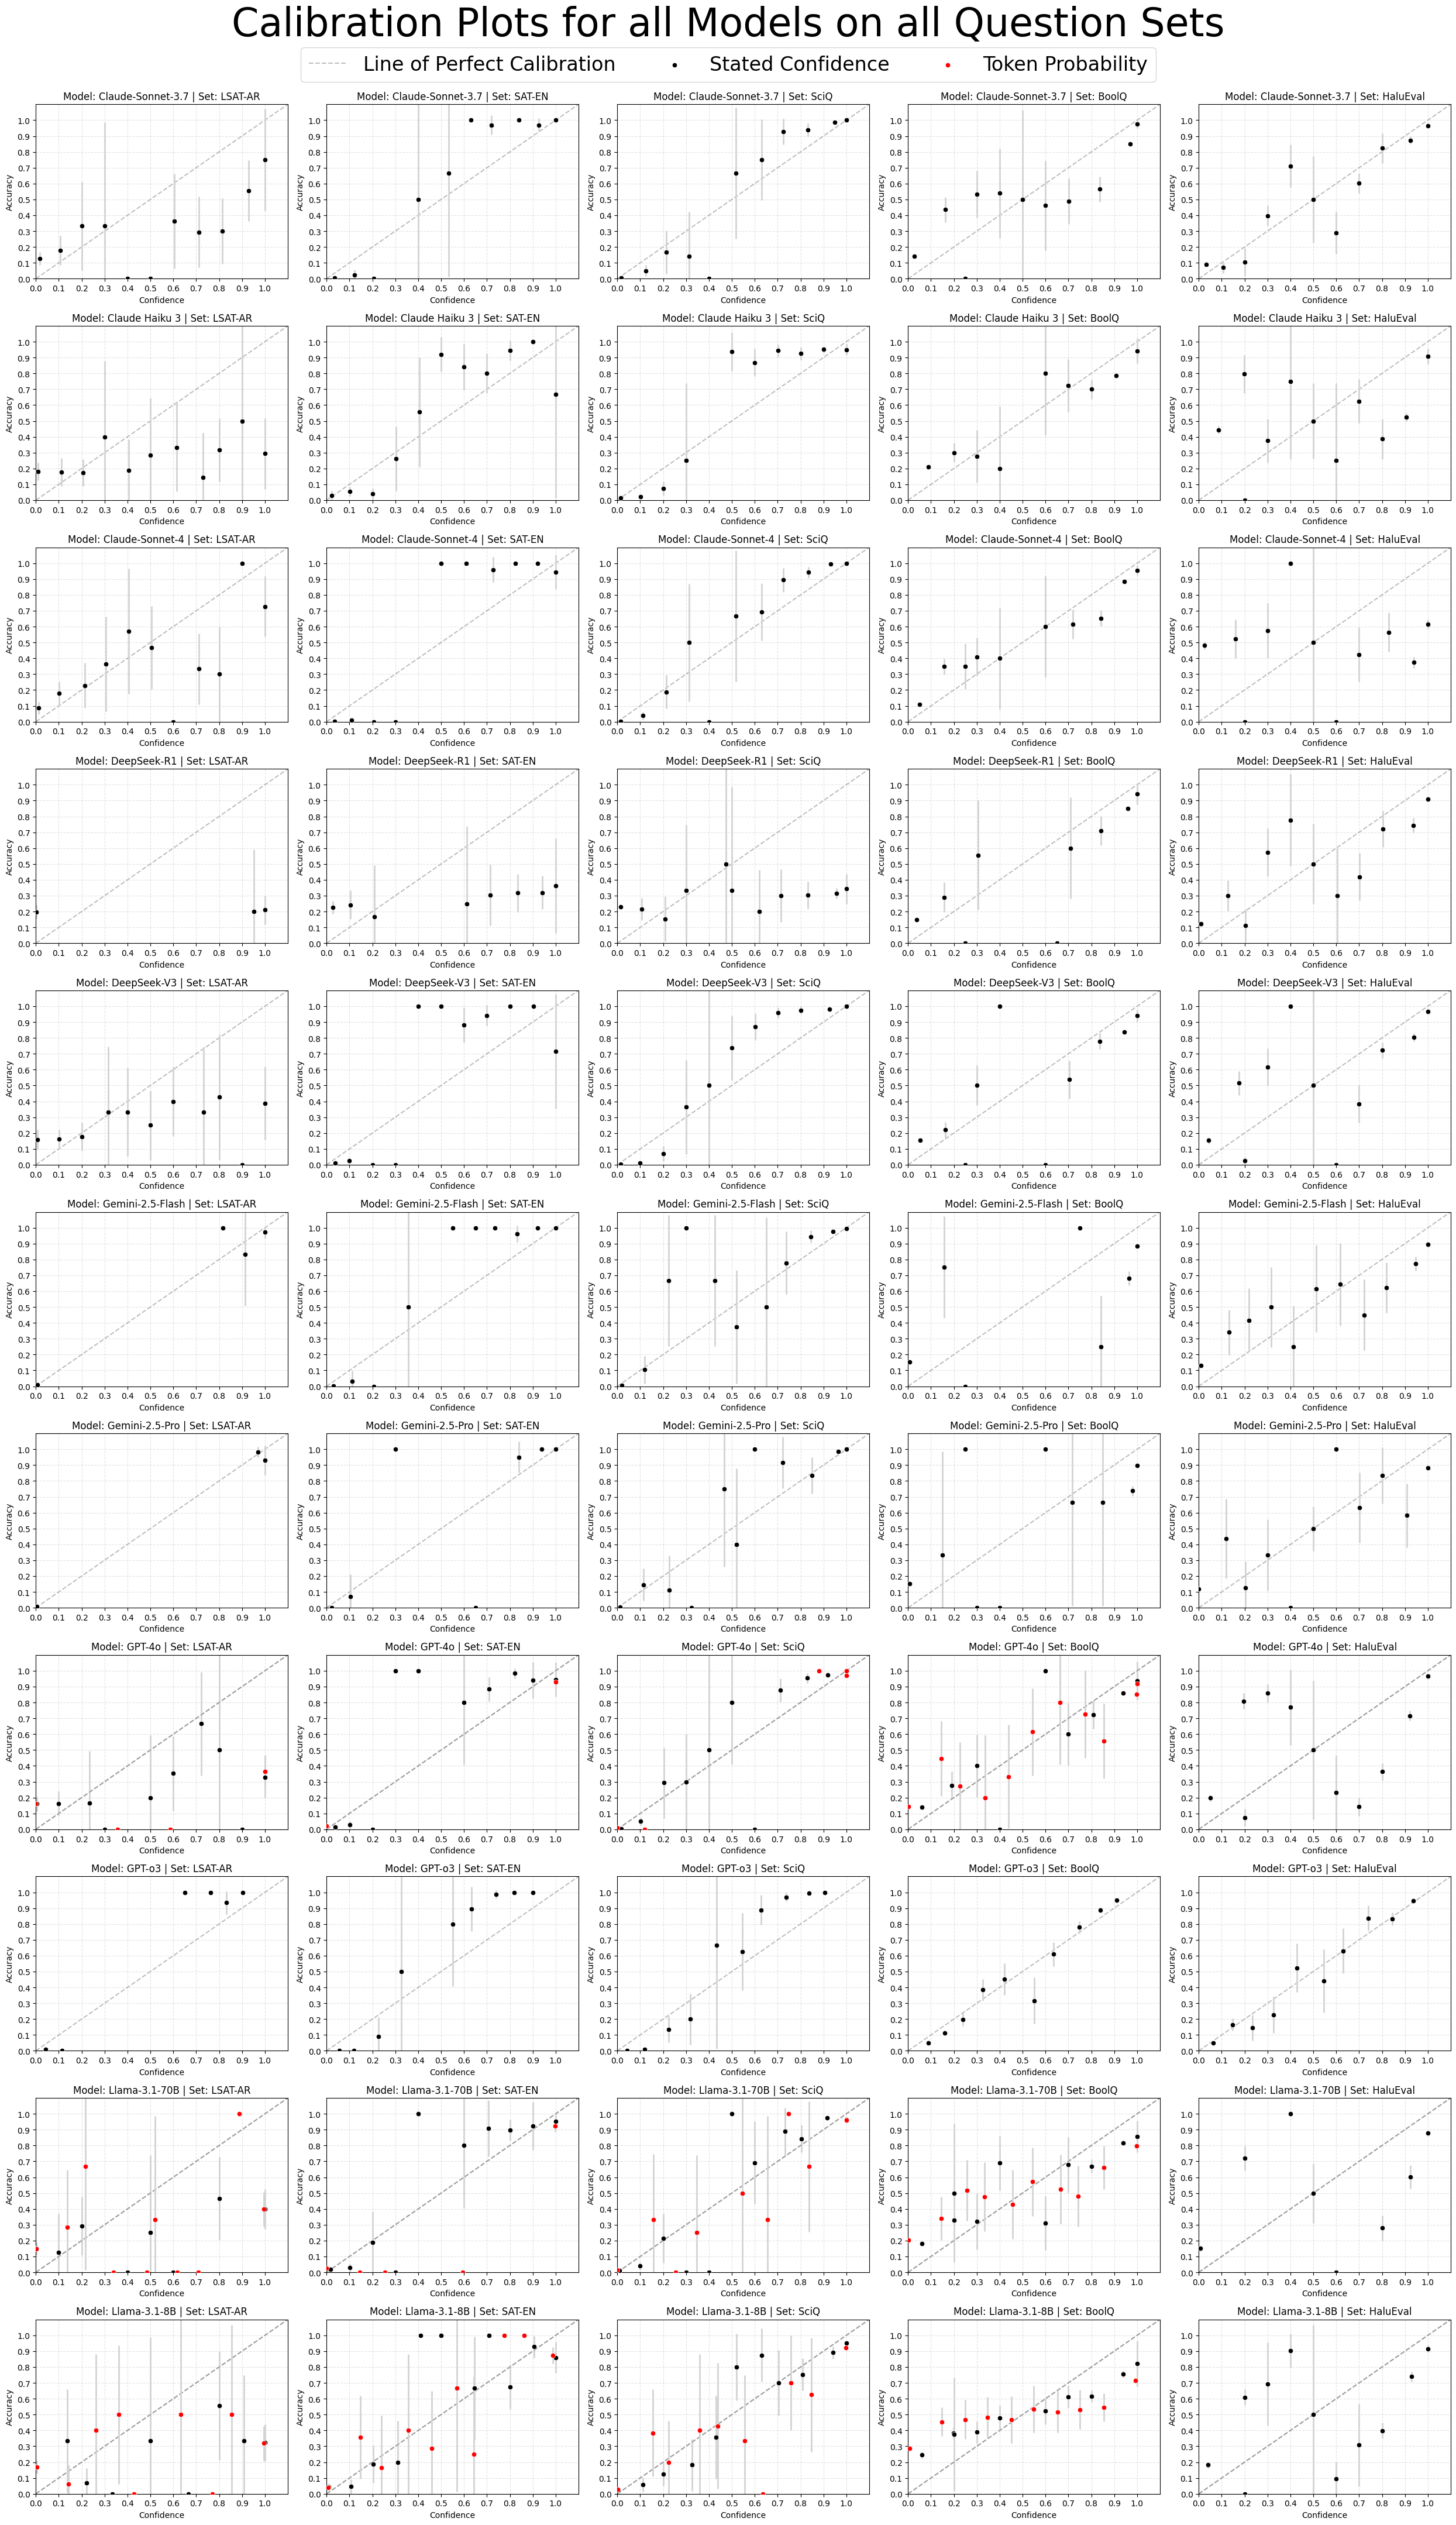

In [47]:
## To Do
# Add in a TP plot when needed
# Add histograms as well


# Expand Stated Confidence for MCQ and 2AFC Qsets
# Extended MCQ

qset_types = {
    "Multiple Choice Questions": ['LSAT-AR', 'SAT-EN', 'SciQ'],
    "2AFC": [ 'BoolQ', 'HaluEval'], # 
}

has_tokens = combined_clean[(~combined_clean['Token Probability A'].isna())]['Model'].unique()

sc_df = pd.DataFrame()

for model in combined_clean['Model'].unique():
    model_subset = combined_clean[combined_clean['Model'] == model]

    for qtype, qsets in qset_types.items():
        ts = tp = np.nan
        #print(qtype, qsets)
        for qset in qsets:
            #print(f"    {qset}") 
            subset = model_subset[model_subset['Question Set'] == qset]
            #print(f"    Subset Length: {len(subset) / 11}")
            title = f"Agregate Performance on {qtype} tasks"

            if qtype == "Multiple Choice Questions":
                scores, conf = expand_mcq(subset)
                if model in has_tokens:
                    ts, tp = expand_mcq(subset, tokens = True)
                #print(f"        Mean Score for {qtype}: {np.mean(scores)}")
                #print(s.mean(), c.mean())
            elif qtype == "2AFC":
                scores, conf = expand_bool(subset)
                if model in has_tokens:
                    if qset != 'HaluEval':
                        ts, tp = expand_bool(subset, tokens = True)
                    else:
                        ts = tp = [np.nan] * len(scores)

            else:
                scores = subset['Score']
                conf = subset['Stated Confidence Answer']

            baby_df = pd.DataFrame({
                "Score": scores,
                "SC": conf,
                "Token Score": ts,
                "Token Probability": tp,
                "Model": [model] * len(scores),
                "Question Set": [qset] * len(scores),
                "Type":[qtype] * len(scores)
            })


            sc_df = pd.concat([sc_df, baby_df], axis=0, ignore_index=True)

sc_df

sc_df['SC'] = sc_df['SC'].astype(float)

# Get unique values for rows and columns


df = sc_df
models = df['Model'].unique()
question_sets = df['Question Set'].unique()

# Create the grid
fig, axes = plt.subplots(
    nrows=len(models), 
    ncols=len(question_sets), 
    figsize=(len(question_sets) * 5, len(models) * 4), 
    squeeze=False
)

for i, model in enumerate(models):
    for j, q_set in enumerate(question_sets):
        ax = axes[i, j]
        # Filter the data for this specific subplot
        subset = df[(df['Model'] == model) & (df['Question Set'] == q_set)]
        
        # Example: Plotting scores for questions in the set
        if not subset.empty:
            calibration_plot(subset, ax=ax, legend = False)
            if model in has_tokens:
                calibration_plot(subset, conf = 'Token Probability', scores = 'Token Score',  ax=ax, legend = False, color = 'red', label = 'Token Probability')
            ax.set_title(f"Model: {model} | Set: {q_set}")
        else:
            ax.set_title(f"No data for {model} - {q_set}")


# Make a main legend

all_handles = {}

# Iterate through every subplot in the grid
for row in axes:
    for ax in row:
        handles, labels = ax.get_legend_handles_labels()
        # Zip them and add to dictionary (overwrites duplicates)
        for handle, label in zip(handles, labels):
            if label not in all_handles:
                all_handles[label] = handle

# Extract the unique lists
unique_labels = list(all_handles.keys())
unique_handles = list(all_handles.values())

fig.tight_layout(rect=[0, 0, 1, 0.95]) 

# 4. POSITION TITLE: Use y to nudge it down closer to the legend
fig.suptitle('Calibration Plots for all Models on all Question Sets', fontsize=48, y=0.98)

# 5. POSITION LEGEND: Use bbox_to_anchor to place it right under the title
fig.legend(
    unique_handles, 
    unique_labels, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.9675), # Nudges it just below the suptitle
    ncol=3, 
    frameon=True,
    prop={'size': 24}

)

plt.show()

In [48]:
sc_df

,Score,SC,Token Score,Token Probability,Model,Question Set,Type
0,0.0,0.00,NaN,NaN,Claude-Sonnet-3.7,LSAT-AR,Multiple Choice Questions
1,0.0,0.00,NaN,NaN,Claude-Sonnet-3.7,LSAT-AR,Multiple Choice Questions
2,1.0,0.95,NaN,NaN,Claude-Sonnet-3.7,LSAT-AR,Multiple Choice Questions
3,0.0,0.05,NaN,NaN,Claude-Sonnet-3.7,LSAT-AR,Multiple Choice Questions
4,0.0,0.00,NaN,NaN,Claude-Sonnet-3.7,LSAT-AR,Multiple Choice Questions
...,...,...,...,...,...,...,...
150563,1.0,0.10,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
150564,1.0,0.90,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
150565,0.0,0.10,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
150566,0.0,0.95,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC


### Stated Confidence V. Token Probability

In [49]:
def expand_mcq_tokens(data):
    """
    This function takes in a dataframe `data` and returns a dataframe which extracts the token / stated confidence values for each option
    The way it's written is pretty inefficient but I wanted clean readable code for debugging.
    """
    df = data.copy()
    sc_list = []
    tp_list = []
    qid_list = []
    qset_list = []
    model_list = []

    kind = ['Multiple Choice Question'] * len(df)

    for index, row in df.iterrows():
        qid = row['Question ID']
        qset = row['Question Set']
        model = row['Model']

        sc_a = row['Stated Confidence A']
        sc_b = row['Stated Confidence B']
        sc_c = row['Stated Confidence C']
        sc_d = row['Stated Confidence D']
        sc_e = row['Stated Confidence E']

        tp_a = row['Token Probability A']
        tp_b = row['Token Probability B']
        tp_c = row['Token Probability C']
        tp_d = row['Token Probability D']
        tp_e = row['Token Probability E']

        if qset == 'LSAT-AR': #only returns True for LSAT-AR
            sc = [sc_a, sc_b, sc_c, sc_d, sc_e]
            tp = [tp_a, tp_b, tp_c, tp_d, tp_e]
        else:
            sc = [sc_a, sc_b, sc_c, sc_d]
            tp = [tp_a, tp_b, tp_c, tp_d]
        
        mini_qid_list = [qid] * len(sc)
        mini_qset_list = [qset] * len(sc)
        mini_model_list = [model] * len(sc)

        sc_list.extend(sc)
        tp_list.extend(tp)
        qid_list.extend(mini_qid_list)
        qset_list.extend(mini_qset_list)
        model_list.extend(mini_model_list)




    kind_list = ['Multiple Choice Questions'] * len(sc_list)

    return pd.DataFrame({
    "Stated Confidence": sc_list,
    "Token Probability": tp_list,
    "Kind": kind_list,
    "Question Set": qset_list,
    "Question ID": qid_list,
    "Model": model_list
    }).dropna(axis = 0)



#### Scatter Plot:

In [50]:

# ## Scatter Plot by Qset type:
# g =sns.jointplot(jp, x='Stated Confidence', y='Token Probability', kind = 'scatter', alpha = 0.1, hue = 'Kind' )

# # Combined Scatter Plot with Regresssion Line 
# #g =sns.jointplot(jp, x='Stated Confidence', y='Token Probability', kind = 'reg')

# # 2. Get the legend handles and labels *from* the joint axis
# handles, labels = g.ax_joint.get_legend_handles_labels()

# # 3. Remove the original, in-plot legend
# g.ax_joint.get_legend().remove()


# # 4. Add a *new* legend to the main figure
# g.figure.legend(handles=handles, 
#              labels=labels, 
#              loc='upper left', 
#              bbox_to_anchor=(1, 1)) # Places it outside

# # 5. (The finicky part) Adjust the figure layout to make space
# # You will have to tinker with 'right' until it looks good.
# g.figure.subplots_adjust(right=1)


#### KDE Plot:

In [51]:
# # KDE Plot:
# for qset_type in jp['Kind'].unique():
#     mini_jp = jp[jp['Kind'] == qset_type]
#     #kind: Literal['scatter', 'kde', 'hist', 'hex', 'reg', 'resid']
#     ax = sns.jointplot(mini_jp, 
#                 x='Stated Confidence', 
#                 y='Token Probability', 
#                 kind='hist',
#                 marginal_kws = {'log_scale': False}
#                 #hue='Kind',
#                 )



#     ax.figure.suptitle(f"Stated Confidence v. Token Probability on {qset_type} Tasks", y=1.02)
#     plt.grid(True) 
#     plt.show()

#     # 3. Remove the original, in-plot legend
#     #g.ax_joint.get_legend().remove()

#     # # 4. Add a *new* legend to the main figure
#     # g.figure.legend(handles=handles, 
#     #             labels=labels, 
#     #             loc='upper left', 
#     #             bbox_to_anchor=(1, 1)) # Places it outside

#     # 5. (The finicky part) Adjust the figure layout to make space
#     # You will have to tinker with 'right' until it looks good.
#     #g.figure.subplots_adjust(right=1)

**Observations**:

* __BoolQ__:
    * For BoolQ, we see that there are some instances where the model described less than 50% confidence (44 instances) these are all by Llama.

#### Investigating the lower right corner of SC v. TP plot

In [52]:
# jp[
#     (jp['Stated Confidence'] >= 0.99)  &
#     (jp['Token Probability'] <= 0.05)
# ]

In [53]:
# bad = only_tokens[
#     (only_tokens['Question ID'] == '73') &  
#     (only_tokens['Question Set'] == 'LSAT-AR')  ]

# content_str = bad.iloc[2]['Content']
# print(content_str)

# Additional Analysis

In [54]:
combined_clean['Stated Confidence Answer (MCQ)'] = combined_clean['Stated Confidence Answer (MCQ)'].astype(float)


res = combined_clean[(combined_clean['Model'] == 'GPT-o3') & 
                     (combined_clean['Question Set'] == 'SAT-EN')].sort_values('Stated Confidence Answer (MCQ)' )['Content'] #(combined_clean['Stated Confidence Answer (MCQ)'] <= 0.5)

print(res.iloc[0])


{
"Reasoning": "If collisions inside the asteroid belt alone destroyed most differentiated bodies, rocks no stronger than primitive asteroids should have been pulverized as well. Thus scientists would expect the belt to contain far fewer surviving primitive asteroids than are actually observed; their surprising abundance is the very fact that shows collisions are not the whole story.",
"Answer": "B",
"A": 0.3,
"B": 0.55,
"C": 0.05,
"D": 0.10
}


## Average Confidence and Accuracy


In [55]:
no_he = combined_clean[combined_clean['Question Set'] != "HaluEval"]
no_he = no_he[["Score", "Stated Confidence Answer", "Stated Confidence Answer (MCQ)"]].astype(float).fillna(0)
no_he['SC'] = np.maximum(no_he['Stated Confidence Answer'], no_he['Stated Confidence Answer (MCQ)'])

w_he = combined_clean[["Score", "Stated Confidence Answer", "Stated Confidence Answer (MCQ)"]].astype(float).fillna(0)
w_he['SC'] = np.maximum(w_he['Stated Confidence Answer'], w_he['Stated Confidence Answer (MCQ)'])

w_he[['Score', 'SC']].astype(float).mean()

Score    0.749217
SC       0.841434
dtype: float64

In [56]:
he = combined_clean[combined_clean["Question Set"] == "HaluEval"]

he['Content'].iloc[5]

'{\n    "Confidence": "0.0"\n}'

In [57]:

# --- 2. Data Preparation ---

# Function to get model family from its name
def get_model_family(model_name):
    if 'Claude' in model_name:
        return 'Claude'
    if 'DeepSeek' in model_name:
        return 'DeepSeek'
    if 'GPT' in model_name:
        return 'GPT'
    if 'Gemini' in model_name:
        return 'Gemini'
    if 'Llama' in model_name:
        return 'Llama'
    return 'Other'

def get_model_type(model_name):
    is_reasoning= ['Claude-Sonnet-3.7', 'Claude-Sonnet-4', 'DeepSeek-R1', 'Gemini-2.5-Pro', 'GPT-o3']
    if model_name in is_reasoning:
        return "Reasoning"
    else:
        return "Chat"

    

# Add the 'Model Family' column to your DataFrame
grouped['Model Family'] = grouped['Model'].apply(get_model_family)

# Define the colors for each family (from your plot)
family_colors = {
    'GPT': '#2ca02c',       # Green
    'Claude': '#1f77b4',    # Blue
    'Gemini': '#9467bd',    # Purple
    'DeepSeek': '#ff7f0e',  # Orange
    'Llama': '#e377c2',     # Pink
    'Other': '#7f7f7f'      # Grey
}

type_colors = {
    "Reasoning": "#9467bd",
    "Chat": "#2ca02c"
}

# Define the shades (alpha) for each radius
# We'll map 1 to be the darkest (alpha=1.0) and 20 to be the lightest
radius_alphas = {1: 1.0, 5: 0.75, 10: 0.5, 20: 0.3}

# Get lists of unique models and radii
models = grouped['Model'].unique()
radii = sorted(grouped['Radius'].unique())
n_models = len(models)
n_radii = len(radii)


# --- 3. Plotting ---

fig, ax = plt.subplots(figsize=(14, 7))

# Define total width for one model's group of bars
group_width = 0.8
# Define width of a single bar
bar_width = group_width / n_radii
# Set the x-axis positions for the center of each group
x_positions = np.arange(n_models)

legend_handles = {}

# Loop over each model to plot its group of bars
for i, model in enumerate(models):
    # Get the data just for this model, sorted by radius
    model_data = grouped[grouped['Model'] == model].sort_values('Radius')
    
    # Loop over each radius to plot its specific bar
    for j, radius in enumerate(radii):
        bar_data = model_data[model_data['Radius'] == radius]
        
        if bar_data.empty:
            continue
            
        # Get the value, family, color, and alpha
        value = bar_data['Stated Overconfidence'].values[0]
        family = bar_data['Model Family'].values[0]
        color = family_colors.get(family, 'grey')
        alpha = radius_alphas.get(radius, 0.5)
        
        # Calculate the x-position for this specific bar
        # Start from the group's center (x_positions[i])
        # Move left by half the group_width
        # Move right by (j * bar_width) to get to this bar's left edge
        # Move right by half a bar_width to get to this bar's center
        x_pos = x_positions[i] - (group_width / 2) + (j * bar_width) + (bar_width / 2)
        
        # Plot the bar
        bar = ax.bar(
            x_pos,
            value,
            width=bar_width,
            color=color,
            alpha=alpha,
            label=family
        )
        
        # Store one bar per family for the legend
        if family not in legend_handles:
            legend_handles[family] = bar

# --- 4. Styling and Labels ---

# Set plot title and labels
#ax.set_title('Comparing Stated Overconfidence at Different Radii for Each Model', fontsize=16)
ax.set_ylabel('Average Overconfidence', fontsize=12)
ax.set_xlabel('Model', fontsize=12)

# Set the x-axis ticks to be the model names
ax.set_xticks(x_positions)
ax.set_xticklabels(models, rotation=45, ha='right' )

# Add the '1 5 10 20' sub-labels
radius_label = ' '.join(map(str, radii))
radius_labels = ['1', '5', '10', '20']
for i in x_positions:
    shift = -bar_width * 2 + 0.5 * bar_width
    for r in radius_labels:
        xpos = i + shift
        ax.text(
            xpos,                      # x-position (center of the group)
            0.05,                  # y-position (just above the x-axis)
            r,           # The text
            ha='center',            # Horizontal alignment
            va='top',               # Vertical alignment
            transform= ax.get_xaxis_transform(), # Use axis coordinates for y
            fontsize=9,
            color='black'
        )

        shift += bar_width

# Add y=0 horizontal line
ax.axhline(0, color='black', linewidth=1.0)
# Add horizontal grid lines
ax.yaxis.grid(True, linestyle='-', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind bars

# Create the legend
ax.legend(
    legend_handles.values(),
    legend_handles.keys(),
    title='Model Families',
    bbox_to_anchor=(1.02, 1), # Position legend outside the plot
    loc='upper left'
)

# Adjust layout to prevent labels from being cut off
plt.subplots_adjust(bottom=0.25, right=0.85)

# Show the plot
plt.show()

KeyError: 'Model'

In [58]:
## Import Human Results

human = pd.read_csv(r"MISC/fin_le_data.csv").drop(columns=["Unnamed: 0", "ResponseId"]).rename(columns={"Radius_x": "Radius"})
human_grouped = human.groupby("Radius").mean()

human_grouped["Stated Overconfidence"] = human_grouped["PConf"] / 100 - human_grouped["Score"]

human_grouped

FileNotFoundError: [Errno 2] No such file or directory: 'MISC/fin_le_data.csv'

In [59]:

# --- 2. Data Preparation ---

# Function to get model family from its name
def get_model_family(model_name):
    if 'Claude' in model_name:
        return 'Claude'
    if 'DeepSeek' in model_name:
        return 'DeepSeek'
    if 'GPT' in model_name:
        return 'GPT'
    if 'Gemini' in model_name:
        return 'Gemini'
    if 'Llama' in model_name:
        return 'Llama'
    return 'Other'

def get_model_type(model_name):
    is_reasoning= ['Claude-Sonnet-3.7', 'Claude-Sonnet-4', 'DeepSeek-R1', 'Gemini-2.5-Pro', 'GPT-o3']
    if model_name in is_reasoning:
        return "Reasoning"
    else:
        return "Chat"

    

# Add the 'Model Family' column to your DataFrame
grouped['Type'] = grouped['Model'].apply(get_model_type)

# Define the colors for each family (from your plot)
family_colors = {
    'GPT': '#2ca02c',       # Green
    'Claude': '#1f77b4',    # Blue
    'Gemini': '#9467bd',    # Purple
    'DeepSeek': '#ff7f0e',  # Orange
    'Llama': '#e377c2',     # Pink
    'Other': '#7f7f7f'      # Grey
}

type_colors = {
    "Reasoning": "#ff7f0e",
    "Chat": "#1f77b4"
}

# Define the shades (alpha) for each radius
# We'll map 1 to be the darkest (alpha=1.0) and 20 to be the lightest
radius_alphas = {1: 1.0, 5: 0.75, 10: 0.5, 20: 0.3}

# Get lists of unique models and radii
models = grouped['Model'].unique()
radii = sorted(grouped['Radius'].unique())
n_models = len(models)
n_radii = len(radii)


# --- 3. Plotting ---

fig, ax = plt.subplots(figsize=(14, 7))

# Define total width for one model's group of bars
group_width = 0.8
# Define width of a single bar
bar_width = group_width / n_radii
# Set the x-axis positions for the center of each group
x_positions = np.arange(n_models + 1)

legend_handles = {}

# Loop over each model to plot its group of bars
for i, model in enumerate(models):
    # Get the data just for this model, sorted by radius
    model_data = grouped[grouped['Model'] == model].sort_values('Radius')
    
    # Loop over each radius to plot its specific bar
    for j, radius in enumerate(radii):
        bar_data = model_data[model_data['Radius'] == radius]
        
        if bar_data.empty:
            continue
            
        # Get the value, family, color, and alpha
        value = bar_data['Stated Overconfidence'].values[0]
        family = bar_data['Type'].values[0]
        color = type_colors.get(family, 'grey')
        alpha = radius_alphas.get(radius, 0.5)
        
        # Calculate the x-position for this specific bar
        # Start from the group's center (x_positions[i])
        # Move left by half the group_width
        # Move right by (j * bar_width) to get to this bar's left edge
        # Move right by half a bar_width to get to this bar's center
        x_pos = x_positions[i] - (group_width / 2) + (j * bar_width) + (bar_width / 2)
        
        # Plot the bar
        bar = ax.bar(
            x_pos,
            value,
            width=bar_width,
            color=color,
            alpha=alpha,
            label=family
        )
        
        # Store one bar per family for the legend
        if family not in legend_handles:
            legend_handles[family] = bar

# --- Add Human Results ---
i += 1
for j, radius in enumerate(radii):
        bar_data = human_grouped#[human_grouped['Radius'] == radius]
        
        if bar_data.empty:
            continue
            
        # Get the value, family, color, and alpha
        value = bar_data['Stated Overconfidence'].loc[radius]
        family = "Human"
        color = "green"
        alpha = radius_alphas.get(radius, 0.5)
        
        # Calculate the x-position for this specific bar
        # Start from the group's center (x_positions[i])
        # Move left by half the group_width
        # Move right by (j * bar_width) to get to this bar's left edge
        # Move right by half a bar_width to get to this bar's center
        x_pos = x_positions[i] - (group_width / 2) + (j * bar_width) + (bar_width / 2)
        
        # Plot the bar
        bar = ax.bar(
            x_pos,
            value,
            width=bar_width,
            color=color,
            alpha=alpha,
            label=family
        )

        
        # Store one bar per family for the legend
        if family not in legend_handles:
            legend_handles[family] = bar






# --- 4. Styling and Labels ---

# Set plot title and labels
#ax.set_title('Comparing Stated Overconfidence at Different Radii for Each Model', fontsize=16)
ax.set_ylabel('Average Overconfidence', fontsize=12)
ax.set_xlabel('Model', fontsize=12)

# Set the x-axis ticks to be the model names
all_labels = np.append(models, "Human Responses")
ax.set_xticks(x_positions)
ax.set_xticklabels(all_labels, rotation=45, ha='right' )

# Add the '1 5 10 20' sub-labels
radius_label = ' '.join(map(str, radii))
radius_labels = ['1', '5', '10', '20']
for i in x_positions:
    shift = -bar_width * 2 + 0.5 * bar_width
    for r in radius_labels:
        xpos = i + shift
        ax.text(
            xpos,                      # x-position (center of the group)
            0.05,                  # y-position (just above the x-axis)
            r,           # The text
            ha='center',            # Horizontal alignment
            va='top',               # Vertical alignment
            transform= ax.get_xaxis_transform(), # Use axis coordinates for y
            fontsize=9,
            color='black'
        )

        shift += bar_width

# Add y=0 horizontal line
ax.axhline(0, color='black', linewidth=1.0)
# Add horizontal grid lines
ax.yaxis.grid(True, linestyle='-', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind bars

# Create the legend
ax.legend(
    legend_handles.values(),
    legend_handles.keys(),
    title='Model Families',
    bbox_to_anchor=(1.02, 1), # Position legend outside the plot
    loc='upper left'
)

# Adjust layout to prevent labels from being cut off
plt.subplots_adjust(bottom=0.25, right=0.85)

# Show the plot
plt.show()

KeyError: 'Model'

In [60]:
bar_data['Stated Overconfidence']

NameError: name 'bar_data' is not defined

In [61]:
only_token_grouped = grouped[grouped['Model'].isin(has_tokens)].copy()

# Function to get model family from its name
def get_model_family(model_name):
    if 'Claude' in model_name:
        return 'Claude'
    if 'DeepSeek' in model_name:
        return 'DeepSeek'
    if 'GPT' in model_name:
        return 'GPT'
    if 'Gemini' in model_name:
        return 'Gemini'
    if 'Llama' in model_name:
        return 'Llama'
    return 'Other'

# Add the 'Model Family' column to your DataFrame
only_token_grouped['Model Family'] = only_token_grouped['Model'].apply(get_model_family)

# Define the colors for each family (from your plot)
family_colors = {
    'GPT': '#2ca02c',       # Green
    'Claude': '#1f77b4',    # Blue
    'Gemini': '#9467bd',    # Purple
    'DeepSeek': '#ff7f0e',  # Orange
    'Llama': '#e377c2',     # Pink
    'Other': '#7f7f7f'      # Grey
}

# Define the shades (alpha) for each radius
# We'll map 1 to be the darkest (alpha=1.0) and 20 to be the lightest
radius_alphas = {1: 1.0, 5: 0.75, 10: 0.5, 20: 0.3}

# Get lists of unique models and radii
models = only_token_grouped['Model'].unique()
radii = sorted(only_token_grouped['Radius'].unique())
n_models = len(models)
n_radii = len(radii)


# --- 3. Plotting ---

fig, ax = plt.subplots(figsize=(14, 7))

# Define total width for one model's group of bars
group_width = 0.8
# Define width of a single bar
bar_width = group_width / n_radii
# Set the x-axis positions for the center of each group
x_positions = np.arange(n_models)

legend_handles = {}

# Loop over each model to plot its group of bars
for i, model in enumerate(models):
    # Get the data just for this model, sorted by radius
    model_data = only_token_grouped[only_token_grouped['Model'] == model].sort_values('Radius')
    
    # Loop over each radius to plot its specific bar
    for j, radius in enumerate(radii):
        bar_data = model_data[model_data['Radius'] == radius]
        
        if bar_data.empty:
            continue
            
        # Get the value, family, color, and alpha
        value = bar_data['Token Overconfidence'].values[0]
        family = bar_data['Model Family'].values[0]
        color = family_colors.get(family, 'grey')
        alpha = radius_alphas.get(radius, 0.5)
        
        # Calculate the x-position for this specific bar
        # Start from the group's center (x_positions[i])
        # Move left by half the group_width
        # Move right by (j * bar_width) to get to this bar's left edge
        # Move right by half a bar_width to get to this bar's center
        x_pos = x_positions[i] - (group_width / 2) + (j * bar_width) + (bar_width / 2)
        
        # Plot the bar
        bar = ax.bar(
            x_pos,
            value,
            width=bar_width,
            color=color,
            alpha=alpha,
            label=family
        )
        
        # Store one bar per family for the legend
        if family not in legend_handles:
            legend_handles[family] = bar

# --- 4. Styling and Labels ---

# Set plot title and labels
ax.set_title('Comparing Token Overconfidence at Different Radii for Each Model', fontsize=16)
ax.set_ylabel('Average Overconfidence', fontsize=12)
ax.set_xlabel('Model', fontsize=12)

# Set the x-axis ticks to be the model names
ax.set_xticks(x_positions)
ax.set_xticklabels(models, rotation=45, ha='right')

# Add the '1 5 10 20' sub-labels
radius_label = ' '.join(map(str, radii))
radius_labels = ['1', '5', '10', '20']
for i in x_positions:
    shift = -bar_width * 2 + 0.5 * bar_width
    for r in radius_labels:
        xpos = i + shift
        ax.text(
            xpos,                      # x-position (center of the group)
            0.05,                  # y-position (just above the x-axis)
            r,           # The text
            ha='center',            # Horizontal alignment
            va='top',               # Vertical alignment
            transform= ax.get_xaxis_transform(), # Use axis coordinates for y
            fontsize=9,
            color='black'
        )

        shift += bar_width

# Add y=0 horizontal line
ax.axhline(0, color='black', linewidth=1.0)
# Add horizontal grid lines
ax.yaxis.grid(True, linestyle='-', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind bars

# Create the legend
ax.legend(
    legend_handles.values(),
    legend_handles.keys(),
    title='Model Families',
    bbox_to_anchor=(1.02, 1), # Position legend outside the plot
    loc='upper left'
)

# Adjust layout to prevent labels from being cut off
plt.subplots_adjust(bottom=0.25, right=0.85)

# Show the plot
plt.show()

KeyError: 'Model'

## Confidence Rounding: Reasoning v. Chat Models


In [62]:
subset

,Score,SC,Token Score,Token Probability,Model,Question Set,Type
146988,0.0,1.00,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
146989,1.0,0.00,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
146990,1.0,1.00,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
146991,0.0,0.00,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
146992,1.0,0.90,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
...,...,...,...,...,...,...,...
150563,1.0,0.10,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
150564,1.0,0.90,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
150565,0.0,0.10,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC
150566,0.0,0.95,NaN,NaN,Llama-3.1-8B,HaluEval,2AFC


In [63]:
combined_clean['Token Probability Answer']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
61012   NaN
61013   NaN
61014   NaN
61015   NaN
61016   NaN
Name: Token Probability Answer, Length: 61017, dtype: float64

In [64]:
reasoning_models = [
    'Claude-Sonnet-3.7',
    'Claude-Sonnet-4',
    'DeepSeek-R1',
    'Gemini-2.5-Pro',
    'GPT-o3',
]

def percent_rounded(df, col: str = 'Stated Confidence Answer'):
    return np.mean((df[col].astype(float) * 100) % 5 == 0)

cc_r = combined_clean[combined_clean['Model'].isin(reasoning_models)]
cc_c = combined_clean[~combined_clean['Model'].isin(reasoning_models)]

print('Stated Confidence:')
print(f'    Reasoning Models: {percent_rounded(cc_r) * 100:.5}% rounded')
print(f'    Chat Models:      {percent_rounded(cc_c) * 100:.5}% rounded')
print('Token Probability:   # Note: we don\u2019t get Token Probs for Reasoning Models')
print(f'    Reasoning Models: {percent_rounded(cc_r, "Token Probability Answer") * 100:.5}% rounded')
print(f'    Chat Models:      {percent_rounded(cc_c, "Token Probability Answer") * 100:.5}% rounded')


Stated Confidence:
    Reasoning Models: 59.524% rounded
    Chat Models:      74.491% rounded
Token Probability:   # Note: we don’t get Token Probs for Reasoning Models
    Reasoning Models: 0.0% rounded
    Chat Models:      0.0% rounded


In [65]:
cc_r['Token Probability Answer'].value_counts()

Series([], Name: count, dtype: int64)

In [66]:
reasoning_models

['Claude-Sonnet-3.7',
 'Claude-Sonnet-4',
 'DeepSeek-R1',
 'Gemini-2.5-Pro',
 'GPT-o3']

<BarContainer object of 1168 artists>

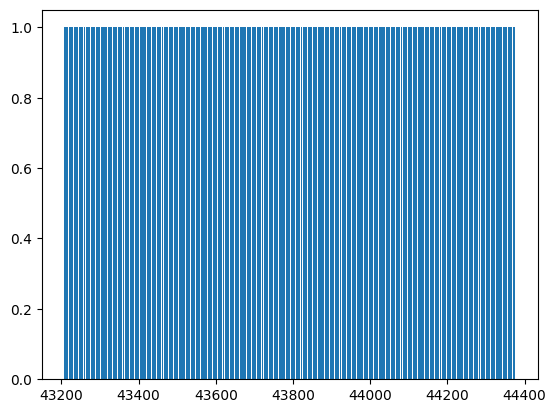

In [67]:
gpt = combined_clean[combined_clean["Model"] == "GPT-4o"][["Question Set", 
                                                           "Question ID",
                                                           "Token Probability A",
                                                           "Token Probability B",
                                                           "Token Probability C",
                                                           "Token Probability D",
                                                           "Token Probability E",]]

gpt_mcq_4 = gpt[(gpt["Question Set"].isin(mcq_qsets)) & (gpt["Question Set"] != "LSAT-AR")][["Question Set", 
                                                           "Question ID",
                                                           "Token Probability A",
                                                           "Token Probability B",
                                                           "Token Probability C",
                                                           "Token Probability D",]]

gpt_mcq_5 = gpt[gpt["Question Set"] == "LSAT-AR"][["Question Set", 
                                                           "Question ID",
                                                           "Token Probability A",
                                                           "Token Probability B",
                                                           "Token Probability C",
                                                           "Token Probability D",
                                                           "Token Probability E"]]


gpt_mcq_4["Smallest"] = gpt_mcq_4[["Token Probability A",
                                    "Token Probability B",
                                    "Token Probability C",
                                    "Token Probability D",]].min(axis = 1)

gpt_mcq_4["Mass of Rest"] = gpt_mcq_4[["Token Probability A",
                                    "Token Probability B",
                                    "Token Probability C",
                                    "Token Probability D",]].sum(axis = 1) - gpt_mcq_4["Smallest"]

sorted = gpt_mcq_4.sort_values("Smallest")


plt.bar(sorted.index, sorted["Mass of Rest"])


In [68]:
gpt_mcq_5

,Question Set,Question ID,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E
43122,LSAT-AR,0,0.000000e+00,1.605228e-09,1.000000e+00,1.103256e-09,4.363462e-09
43123,LSAT-AR,2,0.000000e+00,1.000000e+00,1.605228e-09,5.602796e-09,6.691586e-10
43124,LSAT-AR,3,7.582560e-10,1.000000e+00,3.850742e-09,4.058652e-10,0.000000e+00
43125,LSAT-AR,4,0.000000e+00,3.653482e-08,4.363462e-09,9.999998e-01,1.275191e-07
43126,LSAT-AR,5,1.000000e+00,1.046740e-08,4.363462e-09,9.736200e-10,0.000000e+00
...,...,...,...,...,...,...,...
43203,LSAT-AR,216,3.775135e-11,1.000000e+00,1.416609e-09,0.000000e+00,1.388794e-11
43204,LSAT-AR,219,0.000000e+00,1.067701e-06,6.475935e-07,9.999973e-01,9.422429e-07
43205,LSAT-AR,220,0.000000e+00,6.475947e-07,9.999992e-01,1.275189e-07,4.691164e-08
43206,LSAT-AR,222,1.605228e-09,2.998961e-09,3.653482e-08,1.000000e+00,4.363462e-09


In [69]:
gpt_mcq_5.isin([0])

,Question Set,Question ID,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E
43122,False,False,True,False,False,False,False
43123,False,False,True,False,False,False,False
43124,False,False,False,False,False,False,True
43125,False,False,True,False,False,False,False
43126,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
43203,False,False,False,False,False,True,False
43204,False,False,True,False,False,False,False
43205,False,False,True,False,False,False,False
43206,False,False,False,False,False,False,False


In [70]:
bq = combined_clean[combined_clean['Question Set'] == 'BoolQ']
bq_low = bq[bq["Stated Confidence Answer"] < 0.5]
content = bq_low['Content'].iloc[0]
print(content)

{
    "Reasoning": "This question is asking about the ordering or precedence of P.O. Box addresses versus street addresses, but it's ambiguous what context this refers to. It could mean: (1) alphabetical ordering, (2) postal delivery precedence, (3) address formatting conventions, or (4) some other ordering system. In alphabetical order, 'P' would come after most street names that start with letters A-O. In postal systems, both are valid address types with no inherent precedence. In address formatting, they're typically mutually exclusive - you use one or the other, not both. Without more context about what 'come before' means, I cannot definitively answer this question.",
    "Answer": "False",
    "Confidence": "0.3"
}


In [71]:
bq_low

,Reasoning,Answer,Stated Confidence Answer,Coerce,Content,Question ID,Model,Model Type,Question Set,Score,...,Stated Confidence Answer (MCQ),Token Probability True,Token Probability False,Token Probability Answer,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E,combined_name
11109,This question is asking about the ordering or ...,False,0.3,True,"{\n ""Reasoning"": ""This question is asking a...",20,Claude-Sonnet-4,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20_BoolQ
11169,I don't have access to real-time information a...,False,0.3,True,"{\n ""Reasoning"": ""I don't have access to re...",91,Claude-Sonnet-4,Claude,BoolQ,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91_BoolQ
11211,I need to be careful here as my knowledge has ...,False,0.3,True,"{\n ""Reasoning"": ""I need to be careful here...",148,Claude-Sonnet-4,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148_BoolQ
11393,This question is asking about 'the guy from de...,False,0.1,True,"{\n ""Reasoning"": ""This question is asking a...",394,Claude-Sonnet-4,Claude,BoolQ,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,394_BoolQ
11591,I need to clarify which 'Spirit' series is bei...,False,0.3,True,"{\n ""Reasoning"": ""I need to clarify which '...",650,Claude-Sonnet-4,Claude,BoolQ,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,650_BoolQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57735,I'm not aware of any information about a game ...,False,0.2,True,"{\n ""Reasoning"": ""I'm not aware of any inform...",2961,Llama-3.1-8B,Llama,BoolQ,1.0,...,NaN,0.044752,0.955248,NaN,NaN,NaN,NaN,NaN,NaN,2961_BoolQ
57811,There is no official announcement from the net...,False,0.4,True,"{\n ""Reasoning"": ""There is no official announ...",3062,Llama-3.1-8B,Llama,BoolQ,1.0,...,NaN,0.057393,0.942607,NaN,NaN,NaN,NaN,NaN,NaN,3062_BoolQ
57835,There is no official announcement from Marvel ...,False,0.4,True,"{\n ""Reasoning"": ""There is no official announ...",3094,Llama-3.1-8B,Llama,BoolQ,0.0,...,NaN,0.062250,0.937750,NaN,NaN,NaN,NaN,NaN,NaN,3094_BoolQ
57928,There is no official announcement from the cre...,False,0.4,True,"{\n ""Reasoning"": ""There is no official announ...",3214,Llama-3.1-8B,Llama,BoolQ,0.0,...,NaN,0.016809,0.983191,NaN,NaN,NaN,NaN,NaN,NaN,3214_BoolQ


# Summary Table


Include 

* Accuracy
* Completions
* Confidence
* ECE
* (%) Rounded


## Reasoning


In [72]:
# Reasoning

cc_r



summ_dict = {}

for qset in cc_r["Question Set"].unique():
    #print(f"{qset}:")
    summ_dict[qset] = {}
    for model in cc_r["Model"].unique():
        #print(f"    {model}")
        df = cc_r[(cc_r["Question Set"] == qset) & (cc_r["Model"] == model)]

        acc = df["Score"].astype(float).mean() * 100
        comp = 0
        if qset in mcq_qsets:
            c = df["Stated Confidence Answer (MCQ)"].astype(float)
            ece = get_ece(df["Score"], c)
            p_rounded = percent_rounded(df, col = "Stated Confidence Answer (MCQ)") * 100
            conf = c.mean() * 100


        else:
            conf = df["Stated Confidence Answer"].astype(float).mean() * 100

            ece = get_ece(df["Score"], df["Stated Confidence Answer"])
            p_rounded = percent_rounded(df) * 100


        summ_dict[qset][model] = {
            "Accuracy": acc,
            "Confidence": conf,
            "ECE": ece,
            "(\%) Rounded": p_rounded 
        }


# 1. Convert the nested dictionary into a MultiIndex DataFrame
summ_df = pd.DataFrame.from_dict({
    (qset, model): metrics
    for qset, models in summ_dict.items()
    for model, metrics in models.items()
}, orient='index')

# 2. Name the current index levels
summ_df.index.names = ['Question Set', 'Model']

# 3. Reshape the DataFrame:
# stack() moves the metrics (Accuracy, ECE, etc.) into the index
# unstack('Model') moves the Model names into the columns
summ_df = summ_df.stack().unstack(level='Model')

# 4. Label the index levels for the final output
summ_df.index.names = ['Question Set', 'Metrics']

# Display the result
display(summ_df)

<>:36: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1242742/2690692590.py:36: SyntaxWarning: invalid escape sequence '\%'
  "(\%) Rounded": p_rounded


Model                      Claude-Sonnet-3.7  Claude-Sonnet-4  DeepSeek-R1  \
Question Set Metrics                                                         
BoolQ        Accuracy              83.140232        84.298841    84.498602   
             Confidence            95.574071        91.973232    95.606073   
             ECE                    0.124338         0.080100     0.111075   
             (\%) Rounded          46.064722        96.204555    68.078306   
HaluEval     Accuracy              52.122905        52.122905    52.122905   
             Confidence            59.910056        95.675978    61.071508   
             ECE                    0.080106         0.448380     0.111430   
             (\%) Rounded          99.944134       100.000000    99.273743   
LSAT-AR      Accuracy              41.860465        45.348837    95.348837   
             Confidence            80.930233        71.401809    99.720930   
             ECE                    0.390698         0.331460     0.046047   
             (\%) Rounded          95.348837        94.186047    96.511628   
SAT-EN       Accuracy              97.687861        98.843931    94.219653   
             Confidence            84.156069        82.630058    87.057803   
             ECE                    0.135318         0.165029     0.100058   
             (\%) Rounded          97.109827       100.000000    94.797688   
SciQ         Accuracy              97.286432        96.884422    97.587940   
             Confidence            92.485427        91.718593    93.406633   
             ECE                    0.048814         0.054271     0.041813   
             (\%) Rounded          73.366834        99.597990    66.231156   

Model                         GPT-o3  Gemini-2.5-Pro  
Question Set Metrics                                  
BoolQ        Accuracy      86.056732       84.898122  
             Confidence    82.590491       99.349181  
             ECE            0.044027        0.145310  
             (\%) Rounded  50.379545       73.951258  
HaluEval     Accuracy      52.122905       52.122905  
             Confidence    53.840782       60.136872  
             ECE            0.022240        0.105503  
             (\%) Rounded  55.083799      100.000000  
LSAT-AR      Accuracy      96.511628       96.511628  
             Confidence    81.523256       97.988372  
             ECE            0.149884        0.014767  
             (\%) Rounded  72.093023       37.209302  
SAT-EN       Accuracy      97.687861       98.843931  
             Confidence    75.549133       92.739884  
             ECE            0.221387        0.068555  
             (\%) Rounded  83.815029       63.005780  
SciQ         Accuracy      98.090452       97.587940  
             Confidence    82.649246       95.444020  
             ECE            0.154412        0.031349  
             (\%) Rounded  77.185930       29.748744

In [73]:
def add_midrules_to_groups(latex_str):
    lines = latex_str.splitlines()
    final_lines = []
    
    # Track when we are in the data section (after the header midrule)
    header_passed = False
    
    for i, line in enumerate(lines):
        # Detect the end of the header
        if '\midrule' in line and not header_passed:
            final_lines.append(line)
            header_passed = True
            continue
            
        # If we are in the data:
        # Check if the line starts a new group (doesn't start with space/& and has data)
        if header_passed and '&' in line and not line.startswith(' ') and not line.startswith('\\'):
            # Don't add a midrule if it's the very first data row
            if i > 0 and not final_lines[-1].startswith('\\midrule'):
                final_lines.append('\\midrule')
        
        final_lines.append(line)
        
    return "\n".join(final_lines)

# Usage:
raw_latex = (summ_df.style
    .format(precision=2)  # Round all numbers to 3 decimal places
    .highlight_max(axis=1, props='textbf:--rwrap;') # Bold the best value in each row
    .to_latex(
        hrules=True,
        environment="table*"
    )
)
formatted_latex = add_midrules_to_groups(raw_latex)

print(formatted_latex)

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1242742/1133128584.py:10: SyntaxWarning: invalid escape sequence '\m'
  if '\midrule' in line and not header_passed:


\begin{table*}
\begin{tabular}{llrrrrr}
\toprule
 & Model & Claude-Sonnet-3.7 & Claude-Sonnet-4 & DeepSeek-R1 & GPT-o3 & Gemini-2.5-Pro \\
Question Set & Metrics &  &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{BoolQ} & Accuracy & 83.14 & 84.30 & 84.50 & \textbf{86.06} & 84.90 \\
 & Confidence & 95.57 & 91.97 & 95.61 & 82.59 & \textbf{99.35} \\
 & ECE & 0.12 & 0.08 & 0.11 & 0.04 & \textbf{0.15} \\
 & (\%) Rounded & 46.06 & \textbf{96.20} & 68.08 & 50.38 & 73.95 \\
\multirow[c]{4}{*}{HaluEval} & Accuracy & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} \\
 & Confidence & 59.91 & \textbf{95.68} & 61.07 & 53.84 & 60.14 \\
 & ECE & 0.08 & \textbf{0.45} & 0.11 & 0.02 & 0.11 \\
 & (\%) Rounded & 99.94 & \textbf{100.00} & 99.27 & 55.08 & \textbf{100.00} \\
\multirow[c]{4}{*}{LSAT-AR} & Accuracy & 41.86 & 45.35 & 95.35 & \textbf{96.51} & \textbf{96.51} \\
 & Confidence & 80.93 & 71.40 & \textbf{99.72} & 81.52 & 97.99 \\
 & ECE & \textbf{0.39} & 0.33 & 0.05 & 0.

In [74]:
# Format decimals and convert to LaTeX
latex_code = (summ_df.style
    .format(precision=2)  # Round all numbers to 3 decimal places
    .highlight_max(axis=1, props='textbf:--rwrap;') # Bold the best value in each row
    .to_latex(
        hrules=True,
        caption="Formatted Model Metrics",
        environment="table*"
    )
)

print(latex_code)

\begin{table*}
\caption{Formatted Model Metrics}
\begin{tabular}{llrrrrr}
\toprule
 & Model & Claude-Sonnet-3.7 & Claude-Sonnet-4 & DeepSeek-R1 & GPT-o3 & Gemini-2.5-Pro \\
Question Set & Metrics &  &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{BoolQ} & Accuracy & 83.14 & 84.30 & 84.50 & \textbf{86.06} & 84.90 \\
 & Confidence & 95.57 & 91.97 & 95.61 & 82.59 & \textbf{99.35} \\
 & ECE & 0.12 & 0.08 & 0.11 & 0.04 & \textbf{0.15} \\
 & (\%) Rounded & 46.06 & \textbf{96.20} & 68.08 & 50.38 & 73.95 \\
\multirow[c]{4}{*}{HaluEval} & Accuracy & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} \\
 & Confidence & 59.91 & \textbf{95.68} & 61.07 & 53.84 & 60.14 \\
 & ECE & 0.08 & \textbf{0.45} & 0.11 & 0.02 & 0.11 \\
 & (\%) Rounded & 99.94 & \textbf{100.00} & 99.27 & 55.08 & \textbf{100.00} \\
\multirow[c]{4}{*}{LSAT-AR} & Accuracy & 41.86 & 45.35 & 95.35 & \textbf{96.51} & \textbf{96.51} \\
 & Confidence & 80.93 & 71.40 & \textbf{99.72} & 81.52 & 97.99 \\
 & ECE 

## Chat

In [75]:
# Reasoning



summ_dict = {}

for qset in cc_c["Question Set"].unique():
    #print(f"{qset}:")
    summ_dict[qset] = {}
    for model in cc_c["Model"].unique():
        #print(f"    {model}")
        df = cc_c[(cc_c["Question Set"] == qset) & (cc_c["Model"] == model)]

        acc = df["Score"].astype(float).mean() * 100
        comp = 0
        if qset in mcq_qsets:
            c = df["Stated Confidence Answer (MCQ)"].astype(float)
            ece = get_ece(df["Score"], c)
            p_rounded = percent_rounded(df, col = "Stated Confidence Answer (MCQ)") * 100
            conf = c.mean() * 100


        else:
            conf = df["Stated Confidence Answer"].astype(float).mean() * 100

            ece = get_ece(df["Score"], df["Stated Confidence Answer"])
            p_rounded = percent_rounded(df) * 100


        summ_dict[qset][model] = {
            "Accuracy": acc,
            "Confidence": conf,
            "ECE": ece,
            "(\%) Rounded": p_rounded 
        }


# 1. Convert the nested dictionary into a MultiIndex DataFrame
summ_df = pd.DataFrame.from_dict({
    (qset, model): metrics
    for qset, models in summ_dict.items()
    for model, metrics in models.items()
}, orient='index')

# 2. Name the current index levels
summ_df.index.names = ['Question Set', 'Model']

# 3. Reshape the DataFrame:
# stack() moves the metrics (Accuracy, ECE, etc.) into the index
# unstack('Model') moves the Model names into the columns
summ_df = summ_df.stack().unstack(level='Model')

# 4. Label the index levels for the final output
summ_df.index.names = ['Question Set', 'Metrics']

# Display the result
display(summ_df)

<>:34: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1242742/239584441.py:34: SyntaxWarning: invalid escape sequence '\%'
  "(\%) Rounded": p_rounded


Model                      Claude Haiku 3  DeepSeek-V3      GPT-4o  \
Question Set Metrics                                                 
BoolQ        Accuracy           78.146225    82.900519   85.297643   
             Confidence         89.763084    92.942469   93.257691   
             ECE                 0.117527     0.102217    0.079920   
             (\%) Rounded       99.880144    91.330404   98.361966   
HaluEval     Accuracy           52.122905    52.122905   52.122905   
             Confidence         88.650838    67.162011   76.488827   
             ECE                 0.365838     0.153184    0.244777   
             (\%) Rounded      100.000000   100.000000  100.000000   
LSAT-AR      Accuracy           29.069767    34.883721   36.046512   
             Confidence         67.387245    63.837209   85.581395   
             ECE                 0.420384     0.317442    0.495349   
             (\%) Rounded       89.534884    90.697674   90.697674   
SAT-EN       Accuracy           88.439306    94.797688   93.063584   
             Confidence         67.512228    72.861272   79.393064   
             ECE                 0.220831     0.241908    0.148266   
             (\%) Rounded       98.843931   100.000000   96.531792   
SciQ         Accuracy           94.070352    97.085427   96.884422   
             Confidence         84.348561    86.552764   91.951697   
             ECE                 0.109178     0.105327    0.054151   
             (\%) Rounded       99.798995    98.994975   99.396985   

Model                      Gemini-2.5-Flash  Llama-3.1-70B  Llama-3.1-8B  
Question Set Metrics                                                      
BoolQ        Accuracy             84.538554      78.585697     69.316820  
             Confidence           99.303636      90.600879     85.976149  
             ECE                   0.147651       0.124427      0.170509  
             (\%) Rounded         89.932082      88.174191     96.284459  
HaluEval     Accuracy             52.122905      52.122905     52.122905  
             Confidence           60.287151      63.728492     71.212682  
             ECE                   0.114547       0.143430      0.198719  
             (\%) Rounded         98.603352      99.106145     98.715084  
LSAT-AR      Accuracy             96.511628      38.372093     33.720930  
             Confidence           97.476744      89.534884     88.799559  
             ECE                   0.037558       0.523256      0.574042  
             (\%) Rounded         98.837209     100.000000     94.186047  
SAT-EN       Accuracy             98.843931      91.907514     83.815029  
             Confidence           88.532776      85.815029     85.519647  
             ECE                   0.103112       0.095607      0.115376  
             (\%) Rounded         98.843931      99.421965     94.797688  
SciQ         Accuracy             96.683417      95.376884     91.055276  
             Confidence           93.439196      94.676382     94.514275  
             ECE                   0.039417       0.042040      0.052609  
             (\%) Rounded         78.391960      97.587940     97.286432

In [76]:
# Format decimals and convert to LaTeX
latex_code = (summ_df.style
    .format(precision=2)  # Round all numbers to 3 decimal places
    .highlight_max(axis=1, props='textbf:--rwrap;') # Bold the best value in each row
    .to_latex(
        hrules=True,
        caption="Formatted Model Metrics",
        environment="table*"
    )
)

print(latex_code)

\begin{table*}
\caption{Formatted Model Metrics}
\begin{tabular}{llrrrrrr}
\toprule
 & Model & Claude Haiku 3 & DeepSeek-V3 & GPT-4o & Gemini-2.5-Flash & Llama-3.1-70B & Llama-3.1-8B \\
Question Set & Metrics &  &  &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{BoolQ} & Accuracy & 78.15 & 82.90 & \textbf{85.30} & 84.54 & 78.59 & 69.32 \\
 & Confidence & 89.76 & 92.94 & 93.26 & \textbf{99.30} & 90.60 & 85.98 \\
 & ECE & 0.12 & 0.10 & 0.08 & 0.15 & 0.12 & \textbf{0.17} \\
 & (\%) Rounded & \textbf{99.88} & 91.33 & 98.36 & 89.93 & 88.17 & 96.28 \\
\multirow[c]{4}{*}{HaluEval} & Accuracy & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} & \textbf{52.12} \\
 & Confidence & \textbf{88.65} & 67.16 & 76.49 & 60.29 & 63.73 & 71.21 \\
 & ECE & \textbf{0.37} & 0.15 & 0.24 & 0.11 & 0.14 & 0.20 \\
 & (\%) Rounded & \textbf{100.00} & \textbf{100.00} & \textbf{100.00} & 98.60 & 99.11 & 98.72 \\
\multirow[c]{4}{*}{LSAT-AR} & Accuracy & 29.07 & 34.88 & 36.05 & \textbf{96.

# Token v. Stated ECE


In [77]:
has_tokens = ["GPT-4o", "Llama-3.1-8B","Llama-3.1-70B"]

has_tokens_mask = combined_clean.Model.isin(has_tokens)

tokens = combined_clean[has_tokens_mask]


def get_tpa(df):
    # 1. Define the columns we want to find the max of
    max_cols = [
        "Token Probability True", "Token Probability False",
        "Token Probability A", "Token Probability B",
        "Token Probability C", "Token Probability D",
        "Token Probability E"
    ]
    
    # 2. Calculate the max across those columns for every row (axis=1)
    row_maxes = df[max_cols].max(axis=1)
    
    return pd.Series(row_maxes, index=df.index)

tokens["TP"] = get_tpa(tokens)


res = {}
for qset in tokens["Question Set"].unique():
    res[qset] = {}
    for model in has_tokens:
        df = tokens[(tokens["Model"] == model) & (tokens["Question Set"] == qset)]

        # Get stated ECE
        
        if qset in mcq_qsets:
            c = df["Stated Confidence Answer (MCQ)"].astype(float)
            stated_ece = get_ece(df["Score"], c)
        else:

            stated_ece = get_ece(df["Score"], df["Stated Confidence Answer"])

        
        # Token ECE
        ct = df["TP"]

        token_ece = get_ece(df["Score"], ct)



        res[qset][model] = {
            "Token ECE": token_ece,
            "Stated ECE": stated_ece
        }




In [78]:
# --- 1. Construct the 'flipped' DataFrame from your 'res' dictionary ---
data = []
for qset, models in res.items():
    for model, metrics in models.items():
        data.append({
            "Question Set": qset,
            "Model": model,
            "token": metrics["Token ECE"],
            "stated": metrics["Stated ECE"]
        })

df_flat = pd.DataFrame(data)
# Pivot to get Question Sets as index and Model/Metric as MultiIndex columns
flipped = df_flat.pivot(index="Question Set", columns="Model")
# Swap levels so it matches your access pattern: flipped[model]['stated']
flipped = flipped.swaplevel(0, 1, axis=1).sort_index(axis=1)

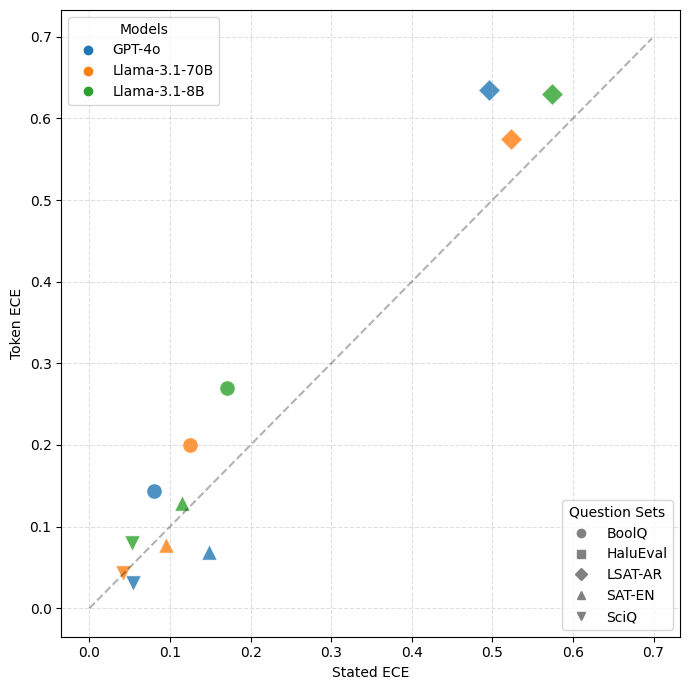

In [79]:
import matplotlib.lines as mlines
# --- 2. Plotting ---
plt.figure(figsize=(7, 7))
plt.grid(True, linestyle='--', alpha=0.4)

# Define marker shapes for Question Sets
# (Add more markers to the list if you have more than 10 question sets)
markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', 'P', 'h']
all_qsets = flipped.index.tolist()
marker_map = {qset: markers[i % len(markers)] for i, qset in enumerate(all_qsets)}

# Define colors for Models
models = flipped.columns.levels[0]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {model: colors[i % len(colors)] for i, model in enumerate(models)}

# Draw diagonal reference line (Perfect Calibration)
all_vals = flipped.values.flatten()
lims = [0, max(all_vals) * 1.1] if len(all_vals) > 0 else [0, 1]
plt.plot(lims, lims, 'k--', alpha=0.3, label="Perfect Calibration")

# Plot each point
for model in models:
    for qset in all_qsets:
        if qset == "HaluEval": continue
        x = flipped.loc[qset, (model, 'stated')]
        y = flipped.loc[qset, (model, 'token')]
        
        # Only plot if values are not NaN
        if pd.notnull(x) and pd.notnull(y):
            plt.scatter(
                x, y, 
                color=color_map[model], 
                marker=marker_map[qset], 
                s=120, 
                alpha=0.8,
                edgecolors='white',
                linewidths=0.5
            )

# Create custom legends
# Legend 1: Models (Colors)
model_legend_handles = [
    mlines.Line2D([], [], color=color_map[m], marker='o', linestyle='None', label=m) 
    for m in models
]
# Legend 2: Question Sets (Shapes)
qset_legend_handles = [
    mlines.Line2D([], [], color='gray', marker=marker_map[q], linestyle='None', label=q) 
    for q in all_qsets
]

# Add legends to the plot
first_legend = plt.legend(handles=model_legend_handles, title="Models", loc="upper left")
plt.gca().add_artist(first_legend) # Manually add the first legend so it isn't overwritten
plt.legend(handles=qset_legend_handles, title="Question Sets", loc="lower right")

plt.xlabel("Stated ECE")
plt.ylabel("Token ECE")
plt.tight_layout()